In [1]:
import os
import numpy as np
import pandas as pd
#import scanpy as sc
import pyranges as pr
import warnings
pd.options.mode.chained_assignment = None  # default='warn'

In [2]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
import matplotlib.patches as patches
import matplotlib.colors as colors
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde, linregress, spearmanr, wilcoxon
from statsmodels.stats.multitest import multipletests

from tabulate import tabulate
from sklearn.decomposition import PCA
import os
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, leaves_list

In [4]:
%matplotlib inline
# figure size & color
matplotlib.rcParams['figure.dpi'] = 100 # 150 dpi resolution
matplotlib.rcParams['image.cmap'] = 'Spectral_r' # preferred color map
matplotlib.rcParams['figure.figsize'] = [8, 8] # Square
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42


# no bounding boxes or axis:
matplotlib.rcParams['axes.spines.bottom'] = "on"
matplotlib.rcParams['axes.spines.top'] = "on"
matplotlib.rcParams['axes.spines.left'] = "on"
matplotlib.rcParams['axes.spines.right'] = "on"
warnings.filterwarnings(action="ignore", module="matplotlib", message="findfont")

In [5]:
font = {#'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 15}

matplotlib.rc('font', **font)
matplotlib.rcParams['axes.linewidth'] = 2 #set the value globally

In [6]:
fig_dir = 'figures'

# Helper functions

In [7]:
# ————————————————————————————————————————————
# Helper to add a black border around axes
def add_frame(ax, lw=1.5):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('black')
        spine.set_linewidth(lw)

# ————————————————————————————————————————————
# Normalization helper for DRUG data
def get_norm_df_drug(df, drug, thresh=0):
    """
    For one histone mark's DRUG dataframe:
      - drug: 'DMSO', 'EED', or 'TAZ'
    Uses meanCPM_<stage>_<drug> columns:
      meanCPM_G1_<drug>, ..., meanCPM_G2_<drug>

    Returns:
      - norm_df: genes × stage columns (G1, S1, S2, S3, S4, G2), values scaled 0–1
      - max_expr: Series of raw max CPM per gene (across stages for that drug)
    """

    # drop TAF11L-prefixed genes
    df = df[~df.index.str.startswith("TAF11L")].copy()

    stages = ["G1", "S1", "S2", "S3", "S4", "G2"]
    mean_cols = [f"meanCPM_{s}_{drug}" for s in stages
                 if f"meanCPM_{s}_{drug}" in df.columns]

    if not mean_cols:
        raise ValueError(f"No meanCPM_<stage>_{drug} columns found in dataframe.")

    # max CPM across stages (for this drug)
    max_expr = df[mean_cols].max(axis=1)

    # optional expression threshold (in CPM units)
    if thresh is not None and thresh > 0:
        keep = max_expr >= thresh
        df = df.loc[keep].copy()
        max_expr = max_expr.loc[keep]

    # normalize each gene's profile to [0,1]
    sel = df[mean_cols].copy()
    row_max = sel.max(axis=1)
    nonzero = row_max != 0
    sel.loc[nonzero] = sel.loc[nonzero].div(row_max[nonzero], axis=0)

    # strip "meanCPM_" and "_<drug>" so columns are just G1,...,G2
    # i.e., meanCPM_G1_DMSO → G1
    new_cols = []
    for c in sel.columns:
        # c like "meanCPM_G1_DMSO"
        parts = c.split("_")  # ["meanCPM", "G1", "DMSO"]
        if len(parts) >= 3:
            new_cols.append(parts[1])  # "G1"
        else:
            new_cols.append(c)
    sel.columns = new_cols

    # ensure correct order of stages
    sel = sel[[s for s in stages if s in sel.columns]]

    return sel, max_expr


# load

In [8]:
marks = ['K27me3','K27me2','K27me1','K27ac','P2S25p']
dfs = []
for mark in marks:
    fp = f'data/2024/RepliTag/Matrices/TAZEED/{mark}_drug_RUVr_series.tsv'
    df = pd.read_csv(fp, sep='\t',index_col = 'Geneid')
    dfs.append(df)

# Add RT

In [9]:
df_path = 'data/2024/RepliTag/Matrices/coverage_scores_gencode.v44.basic.TSS-1000_TES_sorted_bulk.tab'
bins = pd.read_csv(df_path, sep='\t', header = 0)
bins.columns = ['chr','start','end','K27ac', 'K27me1', 'K27me2', 'K27me3', 'RNAPII', 'RT']

TSS_names_path = 'data/2024/K562_annotations/processed_beds/sorted/gencode.v44.basic.TSS-1000_TES_sorted.bed'
TSS_names = pd.read_csv(TSS_names_path, sep='\t', header = None)
TSS_names.columns = ['chr','str', 'end','none1','none2', 'strand','ENSEMBL','Geneid', 'gene']
TSS_names['ID'] = TSS_names['chr'].astype('str') + '_' + TSS_names['str'].astype('str') + '_' +TSS_names['end'].astype('str')
TSS_names.index = TSS_names['Geneid']
TSS_names

bins['ID'] = bins['chr'].astype('str') + '_' + bins['start'].astype('str') + '_' +bins['end'].astype('str')
bins = bins.merge(TSS_names[['ID', 'Geneid']], on='ID', how='left')
bins['RT'] = (bins['RT']/100).clip(upper =1)

# prepare the bins table with Geneid as its index
bins_idx = bins.set_index('Geneid')[['RT','chr','start','end']]
bins_idx = bins_idx.loc[~bins_idx.index.duplicated(keep='first')]

dfs = [
  df.join(bins_idx, how='left')
  for df in dfs
]

In [10]:
rt_data = pd.read_csv('data/2024/LAD_data/JG_coding_genes_maxRPKM.tsv', sep='\t', header = 0, index_col = 0)

dfs = [
  df.join(rt_data['shape_category'], how='left')
  for df in dfs
]

# Linear regression

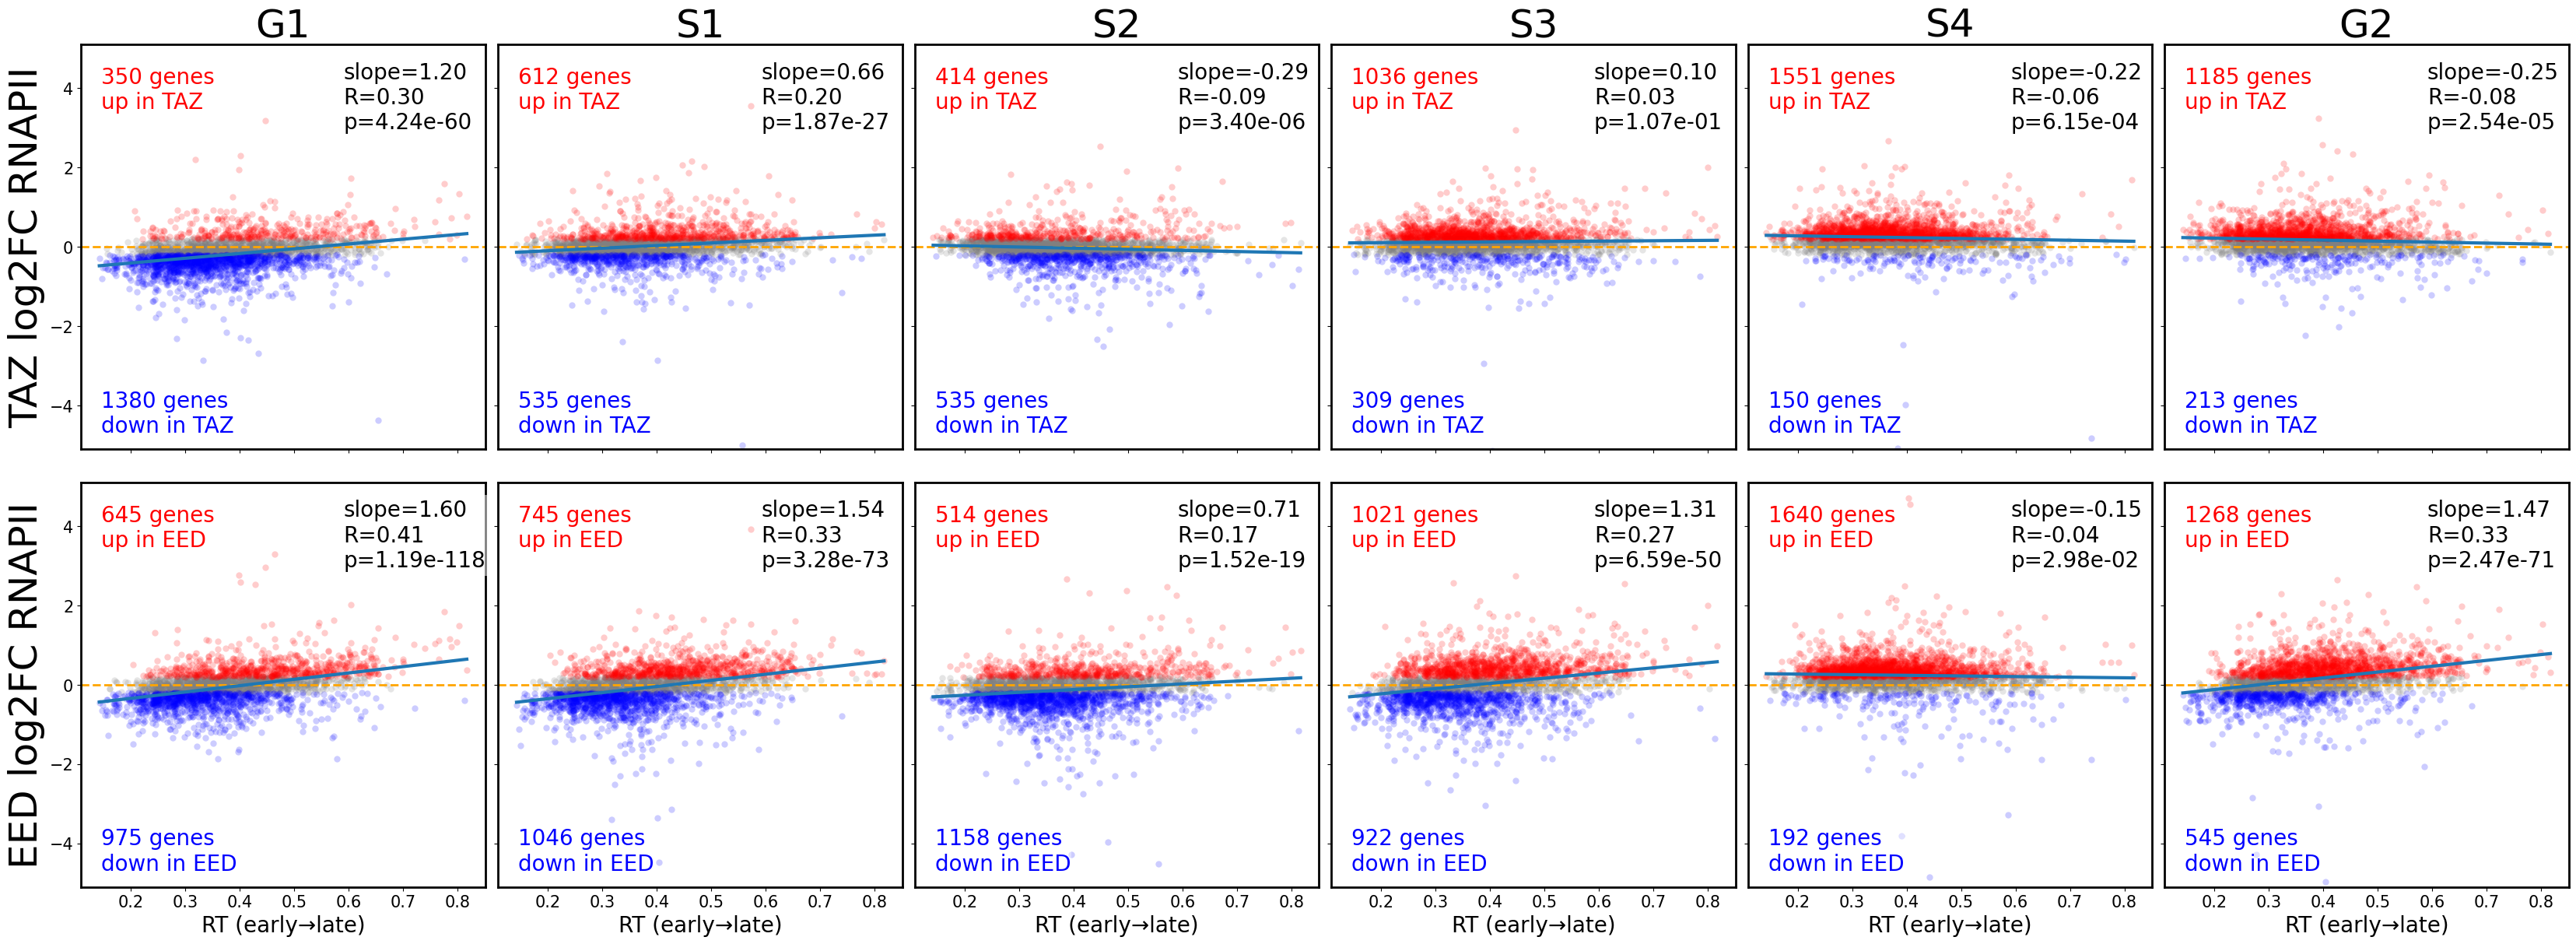

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

marks      = ['K27me3','K27me2','K27me1','K27ac','RNAPII']
drugs      = ['TAZ', 'EED']                       # rows
timepoints = ['G1', 'S1', 'S2', 'S3', 'S4', 'G2']  # columns

# choose a single mark to plot across all subplots
mark_to_plot = 'RNAPII'
mark_idx = marks.index(mark_to_plot)

# dataframe for that mark
df = dfs[mark_idx].copy()
df = df[~df.index.str.startswith("TAF11L")].copy()
df['RT'] = 1 - df['RT']

# rows = drugs, cols = timepoints
fig, axes = plt.subplots(
    nrows=len(drugs),
    ncols=len(timepoints),
    figsize=(5.5 * len(timepoints), 6 * len(drugs)),
    sharex=True,
    sharey=True
)
fig.set_constrained_layout(True)

axes = np.array(axes).reshape(len(drugs), len(timepoints))

# (optional) pre-filter to what you actually plot (same behavior as your masks, just faster)
df_me3 = df[df['shape_category'] == 'me3_domain'].copy()

for i_drug, drug in enumerate(drugs):
    for j_time, time in enumerate(timepoints):
        ax = axes[i_drug, j_time]

        # ----------------------------
        # 1) Compute log2FC (panel-local; DO NOT mutate shared df)
        # ----------------------------
        cpm_drug = df_me3[f'meanCPM_{time}_{drug}']
        cpm_dmso = df_me3[f'meanCPM_{time}_DMSO']
        EFS = 0.01  # same as before

        sub = df_me3.copy()
        sub['log2FC'] = np.log2((cpm_drug + EFS) / (cpm_dmso + EFS))

        # optional: keep FDR if needed (panel-local)
        # fdr_col = f'FDR_{drug}_vs_DMSO_{time}'
        # if fdr_col in sub.columns:
        #     sub['neg_log10_FDR'] = -np.log10(sub[fdr_col])

        # masks (same logic as before)
        sig_mask = (sub['log2FC'].abs() < 0.2)
        up       = (sub['log2FC'] >  0.2)
        down     = (sub['log2FC'] < -0.2)
        
        # fdr_col = f'FDR_{drug}_vs_DMSO_{time}'
        # fdr_col = f'FDR_{drug}_OMNIBUS'
        # sig_mask = (sub[fdr_col] > 0.05)
        # up       = (sub['log2FC'] > 0) & (sub[fdr_col] <= 0.05)
        # down     = (sub['log2FC'] < 0) &(sub[fdr_col] <= 0.05)
        # ----------------------------
        # 2) Scatterplot (UNCHANGED formatting)
        # ----------------------------
        sns.scatterplot(
            y=sub.loc[sig_mask, 'log2FC'],
            x=sub.loc[sig_mask, 'RT'],
            color='gray', ax=ax, alpha=0.2, legend=False, linewidth=0
        )
        sns.scatterplot(
            y=sub.loc[up, 'log2FC'],
            x=sub.loc[up, 'RT'],
            color='red', ax=ax, alpha=0.2, legend=False, linewidth=0
        )
        sns.scatterplot(
            y=sub.loc[down, 'log2FC'],
            x=sub.loc[down, 'RT'],
            color='blue', ax=ax, alpha=0.2, legend=False, linewidth=0
        )

        ax.axhline(y=0, color="orange", linestyle="--", lw=2)

        # make each subplot square (UNCHANGED)
        ax.set_box_aspect(1)
        ax.set_ylim(-5.1, 5.1)

        # ----------------------------
        # 3) Axis labels / titles (UNCHANGED)
        # ----------------------------
        if i_drug == len(drugs) - 1:
            ax.set_xlabel('RT (early→late)', fontsize=20)
        else:
            ax.set_xlabel('')

        if j_time == 0:
            ax.set_ylabel(f'{drug} log2FC {mark_to_plot}', fontsize=36)
        else:
            ax.set_ylabel('')

        if i_drug == 0:
            ax.set_title(time, fontsize=36)

        # ----------------------------
        # 4) Up/down counts annotations (same placement/formatting, but correct per panel)
        # ----------------------------
        up_total = int(up.sum())
        down_total = int(down.sum())

        ax.text(
            0.05, 0.83, f'{up_total} genes\nup in {drug}',
            color='red', ha='left', va='bottom',
            transform=ax.transAxes, fontsize=20,
            bbox=dict(facecolor='white', alpha=0.4, edgecolor='none', pad=0.2)
        )
        ax.text(
            0.05, 0.03, f'{down_total} genes\ndown in {drug}',
            color='blue', ha='left', va='bottom',
            transform=ax.transAxes, fontsize=20,
            bbox=dict(facecolor='white', alpha=0.4, edgecolor='none', pad=0.2)
        )

        # ----------------------------
        # 5) Regression line + stats (same formatting, but correct per panel)
        # ----------------------------
        x = sub['RT'].values
        y = sub['log2FC'].values

        ok = np.isfinite(x) & np.isfinite(y)
        if ok.sum() >= 3 and np.nanstd(x[ok]) > 0:
            lr = linregress(x[ok], y[ok])
            slope, intercept, r, pval = lr.slope, lr.intercept, lr.rvalue, lr.pvalue

            xx = np.linspace(x[ok].min(), x[ok].max(), 100)
            yy = intercept + slope * xx
            ax.plot(xx, yy, linestyle='-', linewidth=3)

            ax.text(
                0.65, 0.78,
                f'slope={slope:.2f}\nR={r:.2f}\np={pval:.2e}',
                transform=ax.transAxes,
                ha='left', va='bottom',
                fontsize=20,
                bbox=dict(facecolor='white', alpha=0.5, edgecolor='none')
            )
        else:
            ax.text(
                0.65, 0.78,
                'slope=NA\nR=NA\np=NA',
                transform=ax.transAxes,
                ha='left', va='bottom',
                fontsize=20,
                bbox=dict(facecolor='white', alpha=0.5, edgecolor='none')
            )
plt.savefig(os.path.join(fig_dir, f"20260217_Sup4d_corrPlot_{mark_to_plot}.pdf"), bbox_inches="tight")
plt.show()


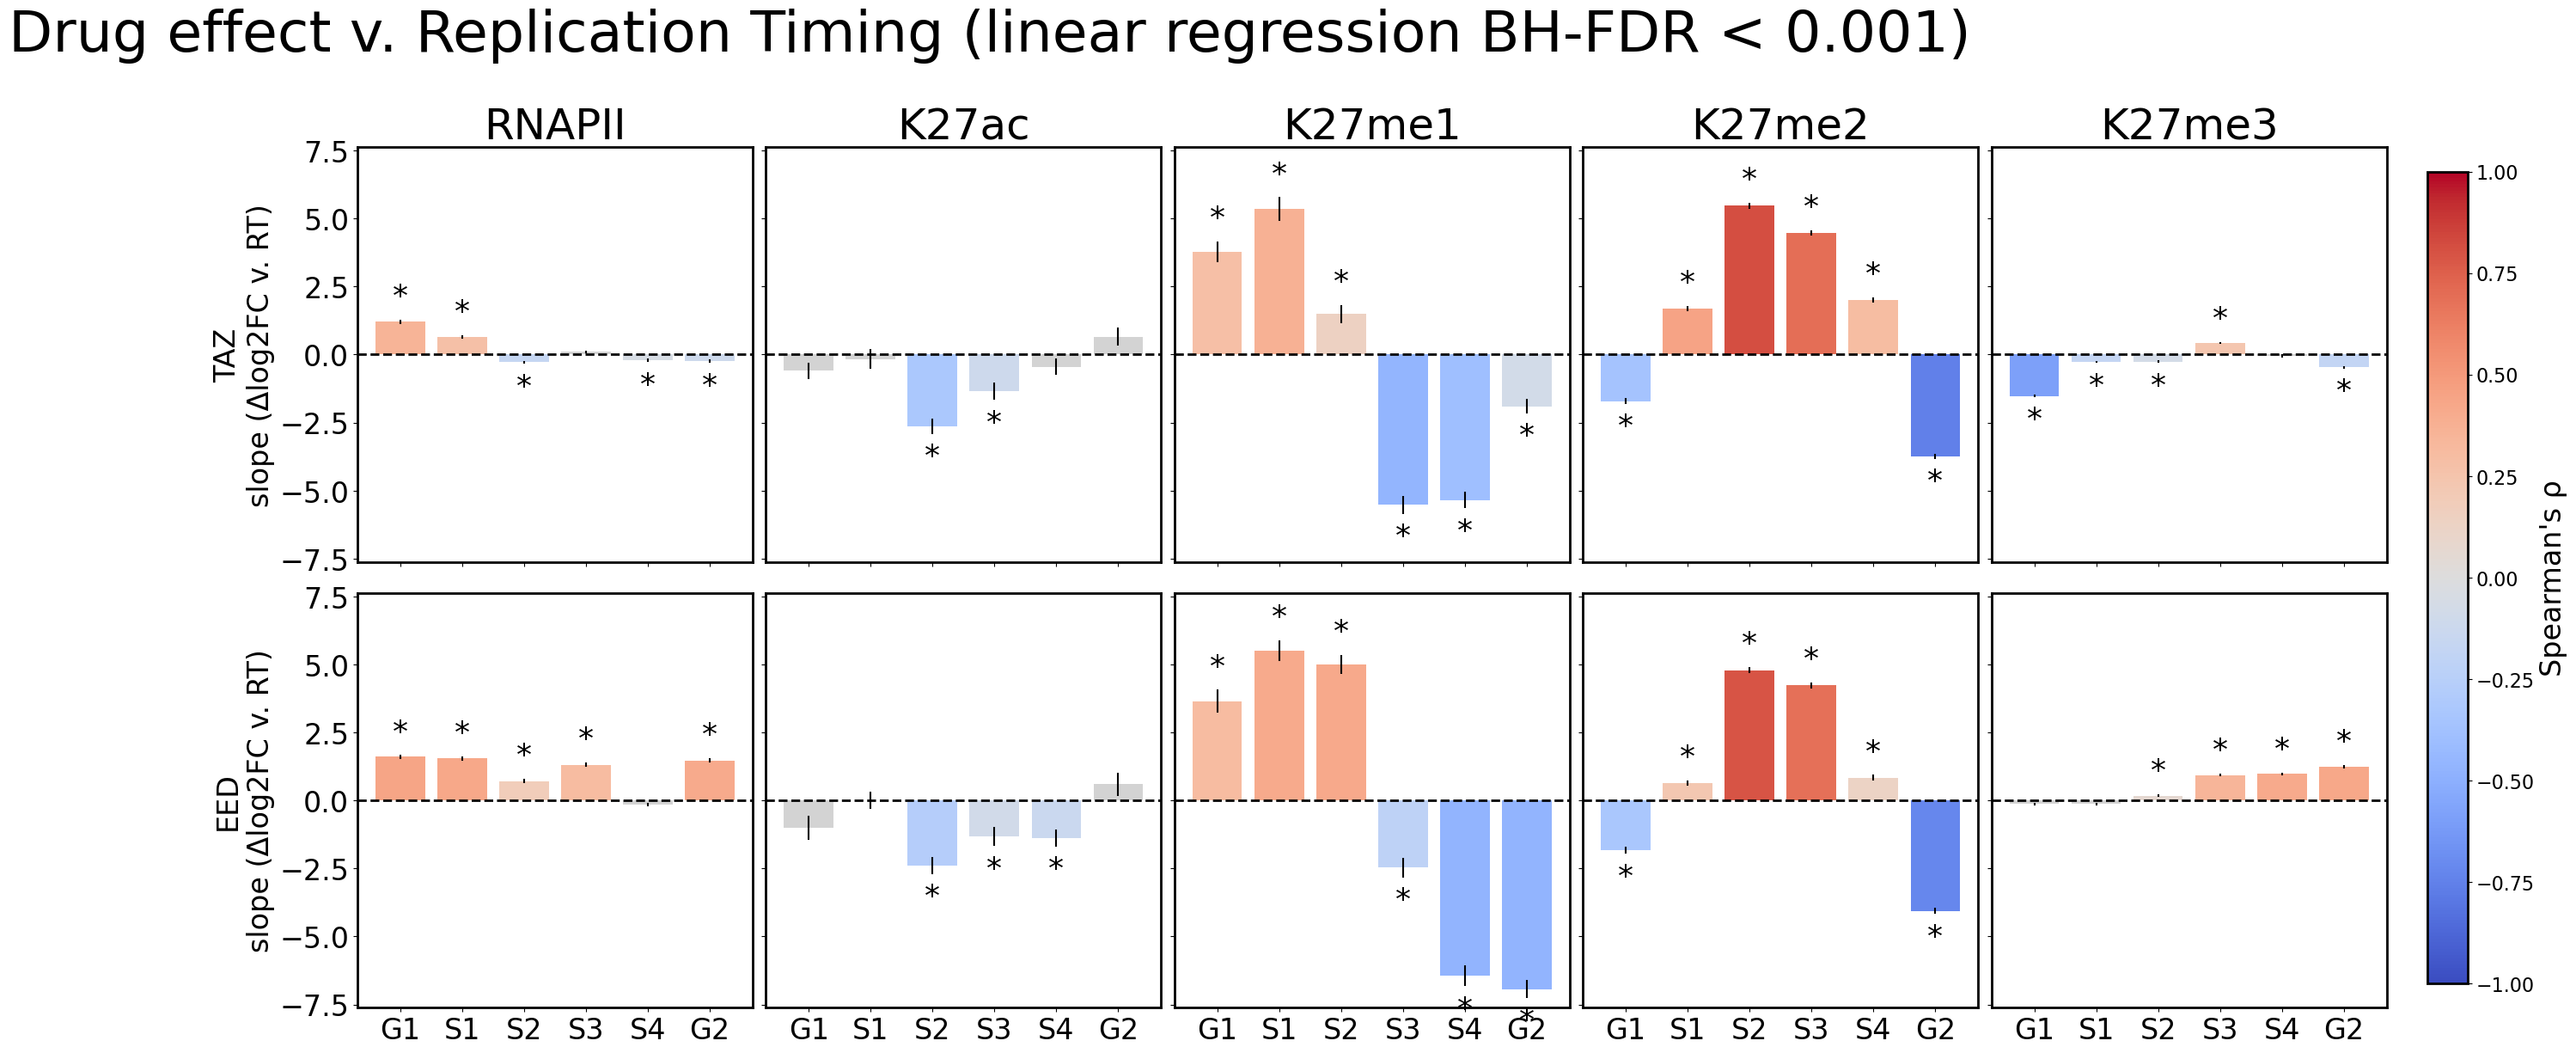

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import linregress, spearmanr

marks      = ['RNAPII', 'K27ac', 'K27me1', 'K27me2', 'K27me3']
timepoints = ['G1', 'S1', 'S2', 'S3', 'S4', 'G2']
drugs      = ["TAZ", "EED"]   # TOP row, BOTTOM row

# assumes dfs is in reverse order relative to marks, as in your original code
mark_to_df = dict(zip(marks[::-1], dfs))
dfs = [mark_to_df[m] for m in marks]

fdr_thresh = 0.001
EFS = 0.01
flip_RT = True
shape_category = "me3_domain"   # set None to disable

def bh_fdr(pvals):
    p = np.asarray(pvals, dtype=float)
    q = np.full_like(p, np.nan, dtype=float)

    ok = np.isfinite(p)
    if ok.sum() == 0:
        return q

    p_ok = p[ok]
    m = p_ok.size
    order = np.argsort(p_ok)
    p_sorted = p_ok[order]
    ranks = np.arange(1, m + 1, dtype=float)

    q_sorted = p_sorted * m / ranks
    q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
    q_sorted = np.clip(q_sorted, 0, 1)

    q_ok = np.empty_like(p_ok)
    q_ok[order] = q_sorted
    q[ok] = q_ok
    return q

def compute_slope_se_rho_p(df_one_mark, tp, drug, EFS=0.01, flip_RT=True, shape_category="me3_domain"):
    d = df_one_mark.copy()

    if d.index.dtype == object:
        d = d[~d.index.str.startswith("TAF11L")].copy()

    if flip_RT:
        d["RT"] = 1 - d["RT"]

    if shape_category is not None and "shape_category" in d.columns:
        d = d[d["shape_category"] == shape_category].copy()

    cpm_drug_col = f"meanCPM_{tp}_{drug}"
    cpm_dmso_col = f"meanCPM_{tp}_DMSO"
    if (cpm_drug_col not in d.columns) or (cpm_dmso_col not in d.columns):
        return np.nan, np.nan, np.nan, np.nan

    x = d["RT"].astype(float).to_numpy()
    cpm_drug = d[cpm_drug_col].astype(float).to_numpy()
    cpm_dmso = d[cpm_dmso_col].astype(float).to_numpy()
    y = np.log2((cpm_drug + EFS) / (cpm_dmso + EFS))

    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() < 3 or np.nanstd(x[ok]) == 0:
        return np.nan, np.nan, np.nan, np.nan

    lr = linregress(x[ok], y[ok])
    slope = float(lr.slope)

    # Use linear regression p-value for significance
    pval = float(lr.pvalue)

    # slope standard error
    if hasattr(lr, "stderr") and lr.stderr is not None and np.isfinite(lr.stderr):
        slope_se = float(lr.stderr)
    else:
        xok = x[ok]
        yok = y[ok]
        n = xok.size
        xbar = xok.mean()
        yhat = lr.intercept + lr.slope * xok
        resid = yok - yhat
        s2 = np.sum(resid**2) / max(n - 2, 1)
        sxx = np.sum((xok - xbar)**2)
        slope_se = float(np.sqrt(s2 / sxx)) if sxx > 0 else np.nan

    # Keep Spearman rho for color only
    rho, _ = spearmanr(x[ok], y[ok], nan_policy="omit")

    return slope, slope_se, float(rho), pval

# stats[drug][mark] -> vectors over timepoints
slopes = {drug: {m: [] for m in marks} for drug in drugs}
ses    = {drug: {m: [] for m in marks} for drug in drugs}
rhos   = {drug: {m: [] for m in marks} for drug in drugs}
ps     = {drug: {m: [] for m in marks} for drug in drugs}

panel_keys = []
p_flat = []

for m_idx, m in enumerate(marks):
    dfm = dfs[m_idx].copy()
    for drug in drugs:
        for tp_i, tp in enumerate(timepoints):
            s, se, rho, p = compute_slope_se_rho_p(
                dfm,
                tp,
                drug,
                EFS=EFS,
                flip_RT=flip_RT,
                shape_category=shape_category
            )
            slopes[drug][m].append(s)
            ses[drug][m].append(se)
            rhos[drug][m].append(rho)
            ps[drug][m].append(p)

            panel_keys.append((drug, m, tp_i))
            p_flat.append(p)

# BH-FDR across all tests using LINEAR REGRESSION p-values
q_flat = bh_fdr(p_flat)

qs = {drug: {m: np.full(len(timepoints), np.nan) for m in marks} for drug in drugs}
for (drug, m, tp_i), q in zip(panel_keys, q_flat):
    qs[drug][m][tp_i] = q

# global y-limits across all panels, including error bars
all_vals = []
for drug in drugs:
    for m in marks:
        s = np.asarray(slopes[drug][m], dtype=float)
        se = np.asarray(ses[drug][m], dtype=float)
        ok = np.isfinite(s) & np.isfinite(se)
        all_vals.extend(list(s[ok] - se[ok]))
        all_vals.extend(list(s[ok] + se[ok]))

all_vals = np.asarray(all_vals, dtype=float)
if np.isfinite(all_vals).any():
    ymax = np.nanmax(np.abs(all_vals[np.isfinite(all_vals)]))
    ylim = (-ymax * 1.05, ymax * 1.05)
else:
    ylim = (-1, 1)

# Plot
fig, axes = plt.subplots(
    2, 5,
    figsize=(5.5 * 5, 5.5 * 2),
    sharex=True,
    sharey=True,
    constrained_layout=True
)
axes = np.array(axes).reshape(2, 5)

cmap = mpl.cm.coolwarm
norm = mpl.colors.Normalize(vmin=-1, vmax=1)

yr = ylim[1] - ylim[0]
star_pad = yr * 0.02

for i, drug in enumerate(drugs):
    for j, m in enumerate(marks):
        ax = axes[i, j]
        x = np.arange(len(timepoints))

        s   = np.asarray(slopes[drug][m], dtype=float)
        se  = np.asarray(ses[drug][m], dtype=float)
        rho = np.asarray(rhos[drug][m], dtype=float)
        q   = np.asarray(qs[drug][m], dtype=float)

        sig = np.isfinite(q) & (q < fdr_thresh) & np.isfinite(s)

        colors = ["lightgray"] * len(timepoints)
        for k in np.where(sig)[0]:
            colors[k] = cmap(norm(float(rho[k])))

        ax.bar(
            x,
            s,
            yerr=se,
            color=colors,
            linewidth=1
        )

        # stars on significant bars
        for k in np.where(sig)[0]:
            yk = float(s[k])
            err = float(se[k]) if np.isfinite(se[k]) else 0.0

            if yk >= 0:
                y_star = yk + err + star_pad
                va = "bottom"
            else:
                y_star = yk - err - star_pad
                va = "top"

            ax.text(k, y_star, "*", ha="center", va=va, fontsize=26)

        ax.axhline(0, color="black", linestyle="--", lw=2)
        ax.set_ylim(*ylim)

        if i == 0:
            ax.set_title(m, fontsize=36)

        ax.set_xticks(x)
        ax.set_xticklabels(timepoints, fontsize=24)
        ax.tick_params(axis="both", labelsize=24)

        if j == 0:
            ax.set_ylabel(f"{drug}\nslope (Δlog2FC v. RT)", fontsize=24)

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), fraction=0.02, pad=0.02)
cbar.set_label("Spearman's ρ", fontsize=24)
cbar.ax.tick_params(labelsize=16)

fig.suptitle(
    f"Drug effect v. Replication Timing (linear regression BH-FDR < {fdr_thresh})",
    fontsize=48,
    y=1.1,
    x=0.33
)

fig.savefig(
    os.path.join(fig_dir, "20260217_Sup4c_corr_barPlot_linearRegressionSig.pdf"),
    bbox_inches="tight"
)

plt.show()

In [13]:
# ------------------------------------------------------------
# Inputs assumed to already exist
# ------------------------------------------------------------
# dfs, fig_dir
# Each df should contain:
#   RT
#   shape_category
#   meanCPM_{tp}_{drug}
#   meanCPM_{tp}_DMSO
# ------------------------------------------------------------

marks      = ['RNAPII', 'K27ac', 'K27me1', 'K27me2', 'K27me3']
timepoints = ['G1', 'S1', 'S2', 'S3', 'S4', 'G2']
drugs      = ['TAZ', 'EED']

# Reorder dfs to match marks above, using your original mapping logic
mark_to_df = dict(zip(marks[::-1], dfs))
dfs = [mark_to_df[m] for m in marks]

# Settings
EFS = 0.01
flip_RT = True
shape_category = "me3_domain"
fdr_thresh = 0.001
fc_thresh = 0.2   # for up/down/stable counts, same as your scatter code

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def bh_fdr(pvals):
    p = np.asarray(pvals, dtype=float)
    q = np.full_like(p, np.nan, dtype=float)

    ok = np.isfinite(p)
    if ok.sum() == 0:
        return q

    p_ok = p[ok]
    m = p_ok.size
    order = np.argsort(p_ok)
    p_sorted = p_ok[order]
    ranks = np.arange(1, m + 1, dtype=float)

    q_sorted = p_sorted * m / ranks
    q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
    q_sorted = np.clip(q_sorted, 0, 1)

    q_ok = np.empty_like(p_ok)
    q_ok[order] = q_sorted
    q[ok] = q_ok
    return q

def prepare_panel_df(df_one_mark, tp, drug, EFS=0.01, flip_RT=True, shape_category="me3_domain"):
    d = df_one_mark.copy()

    if d.index.dtype == object:
        d = d[~d.index.astype(str).str.startswith("TAF11L")].copy()

    if flip_RT:
        d["RT"] = 1 - d["RT"]

    if shape_category is not None and "shape_category" in d.columns:
        d = d[d["shape_category"] == shape_category].copy()

    cpm_drug_col = f"meanCPM_{tp}_{drug}"
    cpm_dmso_col = f"meanCPM_{tp}_DMSO"

    if (cpm_drug_col not in d.columns) or (cpm_dmso_col not in d.columns):
        return None

    d = d.copy()
    d["RT"] = pd.to_numeric(d["RT"], errors="coerce")
    d["cpm_drug"] = pd.to_numeric(d[cpm_drug_col], errors="coerce")
    d["cpm_dmso"] = pd.to_numeric(d[cpm_dmso_col], errors="coerce")
    d["log2FC"] = np.log2((d["cpm_drug"] + EFS) / (d["cpm_dmso"] + EFS))

    d = d[np.isfinite(d["RT"]) & np.isfinite(d["log2FC"])].copy()
    return d

def compute_panel_stats(df_one_mark, tp, drug, EFS=0.01, flip_RT=True, shape_category="me3_domain", fc_thresh=0.2):
    sub = prepare_panel_df(
        df_one_mark=df_one_mark,
        tp=tp,
        drug=drug,
        EFS=EFS,
        flip_RT=flip_RT,
        shape_category=shape_category
    )

    out = {
        "n_genes_total": np.nan,
        "n_up": np.nan,
        "n_down": np.nan,
        "n_stable": np.nan,
        "slope": np.nan,
        "slope_se": np.nan,
        "pearson_r": np.nan,
        "linreg_p": np.nan,
        "spearman_rho": np.nan,
        "spearman_p": np.nan,
    }

    if sub is None or sub.empty:
        return out

    # counts from scatter logic
    up = sub["log2FC"] > fc_thresh
    down = sub["log2FC"] < -fc_thresh
    stable = sub["log2FC"].abs() < fc_thresh

    out["n_genes_total"] = int(len(sub))
    out["n_up"] = int(up.sum())
    out["n_down"] = int(down.sum())
    out["n_stable"] = int(stable.sum())

    x = sub["RT"].to_numpy(dtype=float)
    y = sub["log2FC"].to_numpy(dtype=float)

    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() < 3 or np.nanstd(x[ok]) == 0:
        return out

    xok = x[ok]
    yok = y[ok]

    # linear regression stats used in scatter plot
    lr = linregress(xok, yok)
    out["slope"] = float(lr.slope)
    out["pearson_r"] = float(lr.rvalue)
    out["linreg_p"] = float(lr.pvalue)

    # slope SE used in bar plot
    if hasattr(lr, "stderr") and lr.stderr is not None and np.isfinite(lr.stderr):
        out["slope_se"] = float(lr.stderr)
    else:
        n = xok.size
        xbar = xok.mean()
        yhat = lr.intercept + lr.slope * xok
        resid = yok - yhat
        s2 = np.sum(resid**2) / max(n - 2, 1)
        sxx = np.sum((xok - xbar)**2)
        out["slope_se"] = float(np.sqrt(s2 / sxx)) if sxx > 0 else np.nan

    # spearman stats used for bar color / FDR
    rho, pval = spearmanr(xok, yok, nan_policy="omit")
    out["spearman_rho"] = float(rho)
    out["spearman_p"] = float(pval)

    return out

# ------------------------------------------------------------
# Build long table across all panels
# ------------------------------------------------------------
rows = []

for m, dfm in zip(marks, dfs):
    for drug in drugs:
        for tp in timepoints:
            stats = compute_panel_stats(
                df_one_mark=dfm,
                tp=tp,
                drug=drug,
                EFS=EFS,
                flip_RT=flip_RT,
                shape_category=shape_category,
                fc_thresh=fc_thresh
            )

            rows.append({
                "mark": m,
                "drug": drug,
                "timepoint": tp,
                "shape_category": shape_category,
                "flip_RT": flip_RT,
                "EFS": EFS,
                "fc_thresh": fc_thresh,
                **stats
            })

stats_df = pd.DataFrame(rows)

# ------------------------------------------------------------
# BH-FDR across all panels using LINEAR REGRESSION p-values
# ------------------------------------------------------------
stats_df["linreg_q"] = bh_fdr(stats_df["linreg_p"].to_numpy())
stats_df["significant_fdr"] = stats_df["linreg_q"] < fdr_thresh

# nice ordering
stats_df["mark"] = pd.Categorical(stats_df["mark"], categories=marks, ordered=True)
stats_df["drug"] = pd.Categorical(stats_df["drug"], categories=drugs, ordered=True)
stats_df["timepoint"] = pd.Categorical(stats_df["timepoint"], categories=timepoints, ordered=True)
stats_df = stats_df.sort_values(["drug", "mark", "timepoint"]).reset_index(drop=True)

# ------------------------------------------------------------
# Optional: add a wide-format version too
# ------------------------------------------------------------
stats_wide = stats_df.pivot_table(
    index=["drug", "mark"],
    columns="timepoint",
    values=[
        "n_genes_total", "n_up", "n_down", "n_stable",
        "slope", "slope_se",
        "pearson_r", "linreg_p", "linreg_q",
        "spearman_rho", "spearman_p",
        "significant_fdr"
    ],
    aggfunc="first"
)

# flatten wide columns
stats_wide.columns = [f"{val}_{tp}" for val, tp in stats_wide.columns]
stats_wide = stats_wide.reset_index()

# ------------------------------------------------------------
# Save out
# ------------------------------------------------------------
out_long = os.path.join(fig_dir, "20260217_Sup4c_Sup4d_RT_stats_long.tsv")
out_wide = os.path.join(fig_dir, "20260217_Sup4c_Sup4d_RT_stats_wide.tsv")

stats_df.to_csv(out_long, sep="\t", index=False)
stats_wide.to_csv(out_wide, sep="\t", index=False)

print(f"Saved long table to: {out_long}")
print(f"Saved wide table to: {out_wide}")

# preview
stats_df.head()

/loc/scratch/64485112/ipykernel_24432/1553421822.py:197: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  stats_wide = stats_df.pivot_table(


,mark,drug,timepoint,shape_category,flip_RT,EFS,fc_thresh,n_genes_total,n_up,n_down,n_stable,slope,slope_se,pearson_r,linreg_p,spearman_rho,spearman_p,linreg_q,significant_fdr
0,RNAPII,TAZ,G1,me3_domain,True,0.01,0.2,2855,1362,221,1272,-1.522300,0.042763,-0.554586,5.374099e-230,-0.593312,3.926030e-271,5.374099e-229,True
1,RNAPII,TAZ,S1,me3_domain,True,0.01,0.2,2855,528,284,2043,-0.279901,0.037819,-0.137250,1.768385e-13,-0.178696,6.487737e-22,2.947309e-13,True
2,RNAPII,TAZ,S2,me3_domain,True,0.01,0.2,2855,1223,192,1440,-0.263180,0.040616,-0.120430,1.078293e-10,-0.071421,1.337822e-04,1.658913e-10,True
3,RNAPII,TAZ,S3,me3_domain,True,0.01,0.2,2855,664,345,1846,0.419527,0.040613,0.189877,1.391377e-24,0.242099,2.337495e-39,2.981521e-24,True
4,RNAPII,TAZ,S4,me3_domain,True,0.01,0.2,2855,1351,509,995,-0.044884,0.073585,-0.011419,5.419338e-01,0.008570,6.471710e-01,5.606212e-01,False


# Bubble plots

/loc/scratch/64485112/ipykernel_24432/2537898860.py:185: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pair = sub[sub["time"].isin([t1, t2])].pivot_table(
/loc/scratch/64485112/ipykernel_24432/2537898860.py:185: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pair = sub[sub["time"].isin([t1, t2])].pivot_table(
/loc/scratch/64485112/ipykernel_24432/2537898860.py:185: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pair = sub[sub["time"].isin([t1, t2])].pivot_table(
/loc/scratch/64485112/ipykernel_24432/25378

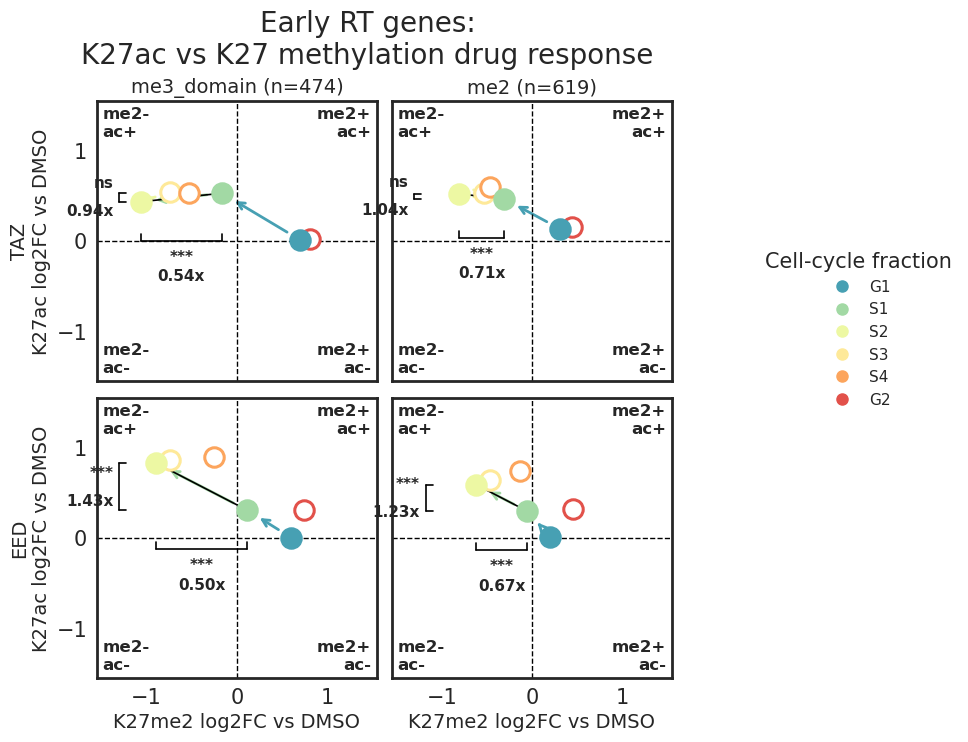

/loc/scratch/64485112/ipykernel_24432/2537898860.py:185: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pair = sub[sub["time"].isin([t1, t2])].pivot_table(
/loc/scratch/64485112/ipykernel_24432/2537898860.py:185: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pair = sub[sub["time"].isin([t1, t2])].pivot_table(
/loc/scratch/64485112/ipykernel_24432/2537898860.py:185: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pair = sub[sub["time"].isin([t1, t2])].pivot_table(
/loc/scratch/64485112/ipykernel_24432/25378

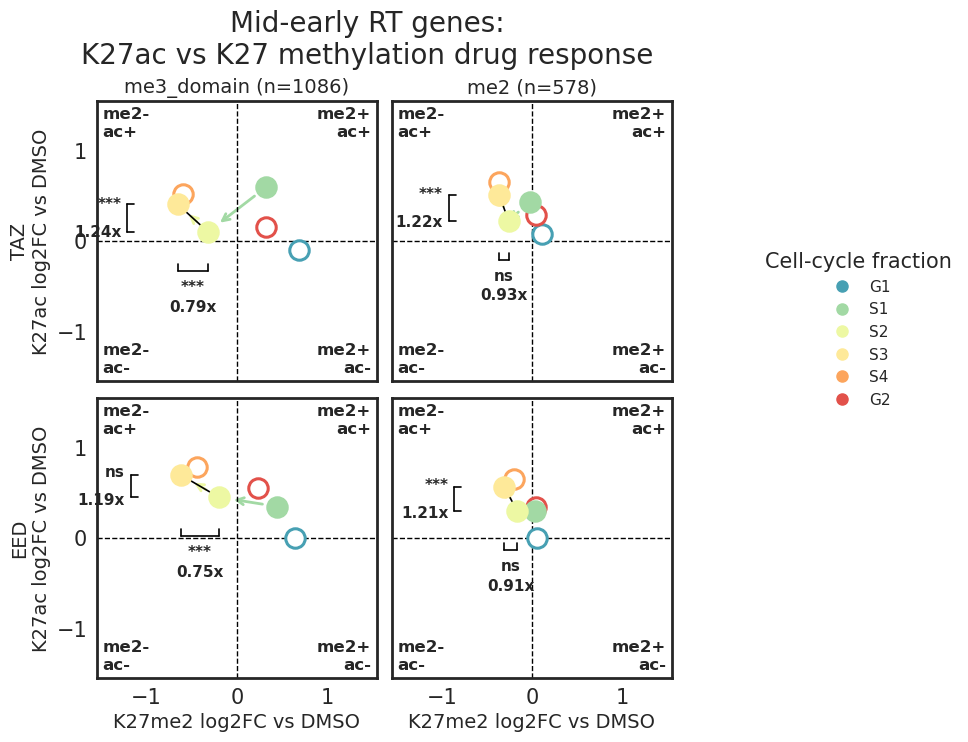

/loc/scratch/64485112/ipykernel_24432/2537898860.py:185: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pair = sub[sub["time"].isin([t1, t2])].pivot_table(
/loc/scratch/64485112/ipykernel_24432/2537898860.py:185: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pair = sub[sub["time"].isin([t1, t2])].pivot_table(
/loc/scratch/64485112/ipykernel_24432/2537898860.py:185: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pair = sub[sub["time"].isin([t1, t2])].pivot_table(
/loc/scratch/64485112/ipykernel_24432/25378

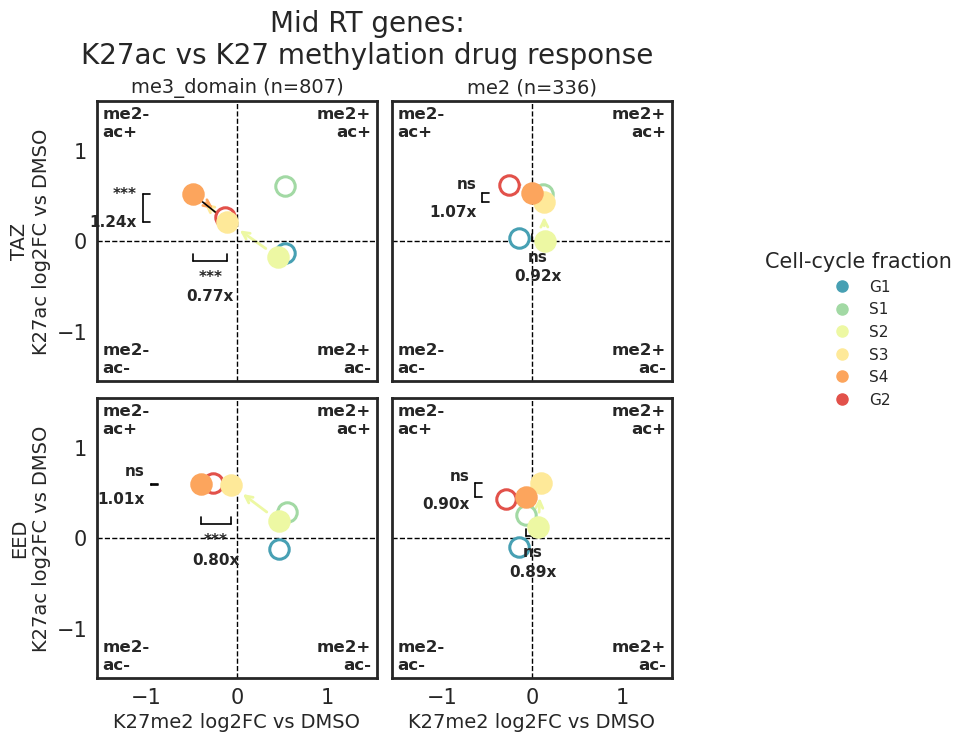

/loc/scratch/64485112/ipykernel_24432/2537898860.py:185: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pair = sub[sub["time"].isin([t1, t2])].pivot_table(
/loc/scratch/64485112/ipykernel_24432/2537898860.py:185: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pair = sub[sub["time"].isin([t1, t2])].pivot_table(
/loc/scratch/64485112/ipykernel_24432/2537898860.py:185: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pair = sub[sub["time"].isin([t1, t2])].pivot_table(
/loc/scratch/64485112/ipykernel_24432/25378

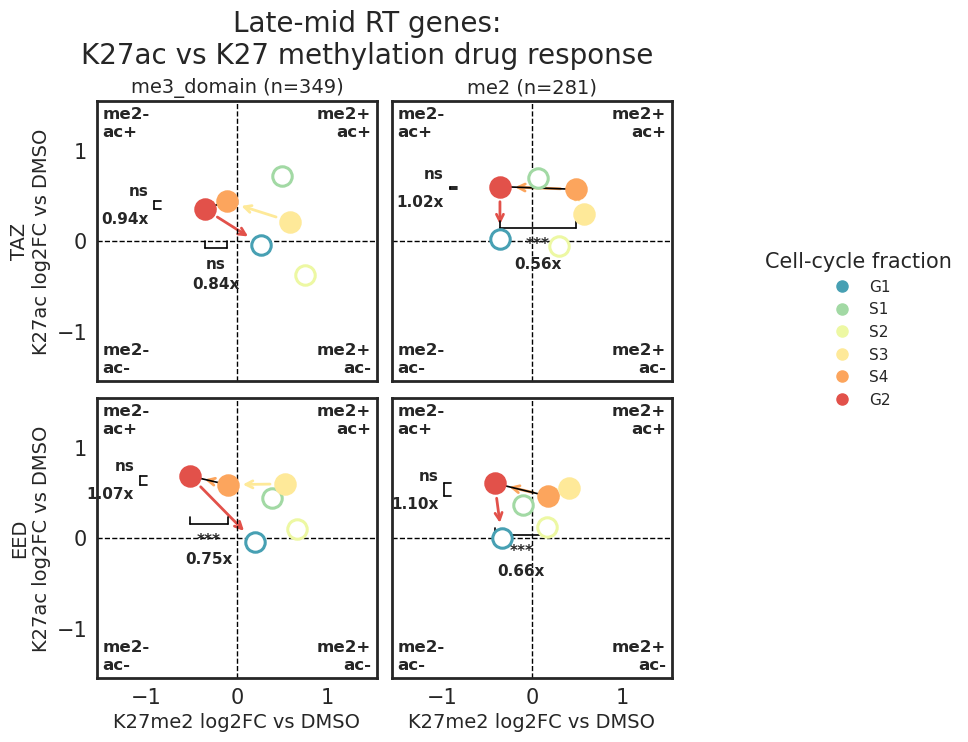

In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.lines import Line2D
from scipy.stats import wilcoxon

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------
marks = ['K27me3', 'K27me2', 'K27me1', 'K27ac', 'RNAPII']
drugs = ['TAZ', 'EED']
cats = ['me3_domain', 'me2']
x_marks = ['K27me2', 'K27me3']
times = ['G1', 'S1', 'S2', 'S3', 'S4', 'G2']
EFS = 0.01

xlim = (-1.55, 1.55)
ylim = (-1.55, 1.55)

MIN_FOLD_CHANGE_FROM_NULL = 0.2

marker_size = 14
marker_edgewidth = 2.2
arrow_lw = 2.0
arrow_scale_with_marker = 1.15

# 3 highlighted points per RT bin
rt_highlight_map = {
    "Early RT":     ["G1", "S1", "S2"],
    "Mid-early RT": ["S1", "S2", "S3"],
    "Mid RT":       ["S2", "S3", "S4"],
    "Late-mid RT":  ["S3", "S4", "G2"],
}

# stats only between final 2 highlighted points
rt_pair_map = {
    "Early RT":     ("S1", "S2"),
    "Mid-early RT": ("S2", "S3"),
    "Mid RT":       ("S3", "S4"),
    "Late-mid RT":  ("S4", "G2"),
}

# ------------------------------------------------------------
# Shared mark table setup
# ------------------------------------------------------------
use_marks = ['K27me2', 'K27me3', 'K27ac']
mark_dfs = {m: dfs[marks.index(m)].copy() for m in use_marks}

common = mark_dfs['K27ac'].index.copy()
for m in ['K27me2', 'K27me3']:
    common = common.intersection(mark_dfs[m].index)

bad = (
    common.astype(str).str.startswith("TAF11L")
    | common.astype(str).str.startswith("FAM90A")
    | common.astype(str).str.startswith("USP17L")
)

for m in use_marks:
    mark_dfs[m] = mark_dfs[m].loc[common[~bad]].copy()

same_cat = (
    mark_dfs['K27ac']['shape_category'].astype(str).eq(mark_dfs['K27me2']['shape_category'].astype(str))
    & mark_dfs['K27ac']['shape_category'].astype(str).eq(mark_dfs['K27me3']['shape_category'].astype(str))
)
for m in use_marks:
    mark_dfs[m] = mark_dfs[m].loc[same_cat].copy()

# ------------------------------------------------------------
# RT bins
# ------------------------------------------------------------
rt_bins = np.linspace(
    np.quantile(rt_data['RT'].dropna(), 0.02),
    np.quantile(rt_data['RT'].dropna(), 0.98),
    7
)
rt_bins[0], rt_bins[-1] = 0, 1

rt_labels = ["Early RT", "Mid-early RT", "Mid RT", "Late-mid RT", "Mid-late RT", "Late RT"]
rt_label_map = dict(enumerate(rt_labels))

rt_bin_assignment = pd.cut(
    1 - bins_idx['RT'],
    bins=rt_bins,
    labels=range(len(rt_labels)),
    include_lowest=True,
    right=True
)

valid_idx = rt_bin_assignment.dropna().index
for m in use_marks:
    valid_idx = valid_idx.intersection(mark_dfs[m].index)

for m in use_marks:
    mark_dfs[m] = mark_dfs[m].loc[valid_idx].copy()
    mark_dfs[m]["rt_bin"] = rt_bin_assignment.loc[valid_idx].astype(int)
    mark_dfs[m]["rt_label"] = mark_dfs[m]["rt_bin"].map(rt_label_map)

# ------------------------------------------------------------
# Long table
# ------------------------------------------------------------
rows = []
for cat in cats:
    genes = mark_dfs['K27ac'].index[mark_dfs['K27ac']["shape_category"] == cat]
    if len(genes) == 0:
        continue

    ac = mark_dfs['K27ac'].loc[genes].copy()

    for x_mark in x_marks:
        xdf = mark_dfs[x_mark].loc[genes].copy()

        for drug in drugs:
            for time in times:
                x1, x0 = f"meanCPM_{time}_{drug}", f"meanCPM_{time}_DMSO"
                if not all(c in xdf.columns for c in [x1, x0]):
                    continue
                if not all(c in ac.columns for c in [x1, x0]):
                    continue

                tmp = pd.DataFrame({
                    "gene": genes,
                    "category": cat,
                    "x_mark": x_mark,
                    "drug": drug,
                    "time": time,
                    "rt_bin": ac["rt_bin"].values,
                    "rt_label": ac["rt_label"].values,
                    "x_log2FC": np.log2((xdf[x1].astype(float) + EFS) / (xdf[x0].astype(float) + EFS)).values,
                    "K27ac_log2FC": np.log2((ac[x1].astype(float) + EFS) / (ac[x0].astype(float) + EFS)).values,
                })
                tmp = tmp.replace([np.inf, -np.inf], np.nan).dropna(subset=["x_log2FC", "K27ac_log2FC"])
                rows.append(tmp)

plot_df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(
    columns=["gene", "category", "x_mark", "drug", "time", "rt_bin", "rt_label", "x_log2FC", "K27ac_log2FC"]
)

plot_df["time"] = pd.Categorical(plot_df["time"], categories=times, ordered=True)
plot_df["rt_label"] = pd.Categorical(plot_df["rt_label"], categories=rt_labels, ordered=True)

time_color_map = dict(zip(times, sns.color_palette("Spectral_r", len(times))))

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def effect_passes_fold(fold, min_fc_from_null=MIN_FOLD_CHANGE_FROM_NULL):
    return np.isfinite(fold) and ((fold <= 1 - min_fc_from_null) or (fold >= 1 + min_fc_from_null))

def p_to_stars_with_effect(p, fold):
    if pd.isna(p):
        return "NA"
    if not effect_passes_fold(fold):
        return "ns"
    return "***" if p < 1e-3 else "**" if p < 1e-2 else "*" if p < 5e-2 else "ns"

def safe_wilcoxon(d):
    d = np.asarray(d, float)
    d = d[np.isfinite(d)]
    if len(d) == 0:
        return np.nan
    if np.allclose(d, 0):
        return 1.0
    try:
        return wilcoxon(d, zero_method="wilcox", alternative="two-sided").pvalue
    except ValueError:
        return np.nan

def get_group_summary(sub):
    out = {}
    for t in times:
        g = sub[sub["time"] == t].dropna(subset=["x_log2FC", "K27ac_log2FC"])
        if not g.empty:
            out[t] = {
                "x_med": g["x_log2FC"].median(),
                "y_med": g["K27ac_log2FC"].median(),
                "n": len(g),
            }
    return out

def get_pair_stats(sub, t1, t2):
    pair = sub[sub["time"].isin([t1, t2])].pivot_table(
        index="gene",
        columns="time",
        values=["x_log2FC", "K27ac_log2FC"],
        aggfunc="first"
    )

    out = dict(x_p=np.nan, y_p=np.nan, x_fold=np.nan, y_fold=np.nan)

    for val in ["x_log2FC", "K27ac_log2FC"]:
        if (val, t1) in pair.columns and (val, t2) in pair.columns:
            z = pair[[(val, t1), (val, t2)]].dropna()
            if not z.empty:
                med1 = z[(val, t1)].median()
                med2 = z[(val, t2)].median()
                p = safe_wilcoxon(z[(val, t2)] - z[(val, t1)])
                fold = 2 ** (med2 - med1)
                prefix = "x" if val == "x_log2FC" else "y"
                out[f"{prefix}_p"] = p
                out[f"{prefix}_fold"] = fold
    return out

def draw_pair_annotation(ax, summary, stats, t1, t2, xlim, ylim):
    if t1 not in summary or t2 not in summary:
        return

    x1, y1 = summary[t1]["x_med"], summary[t1]["y_med"]
    x2, y2 = summary[t2]["x_med"], summary[t2]["y_med"]
    xr = xlim[1] - xlim[0]
    yr = ylim[1] - ylim[0]

    # median connector under points
    ax.plot([x1, x2], [y1, y2], color="black", lw=1.2, zorder=2)

    # vertical bracket under points
    x_br = max(min(x1, x2) - 0.18 * xr, xlim[0] + 0.08 * xr)
    y_low, y_high = sorted([y1, y2])
    ax.plot([x_br, x_br], [y_low, y_high], color="black", lw=1.2, zorder=2)
    ax.plot([x_br, x_br + 0.025 * xr], [y_low, y_low], color="black", lw=1.2, zorder=2)
    ax.plot([x_br, x_br + 0.025 * xr], [y_high, y_high], color="black", lw=1.2, zorder=2)

    # horizontal bracket under points
    y_br = max(min(y1, y2) - 0.14 * yr, ylim[0] + 0.08 * yr)
    x_low, x_high = sorted([x1, x2])
    ax.plot([x_low, x_high], [y_br, y_br], color="black", lw=1.2, zorder=2)
    ax.plot([x_low, x_low], [y_br, y_br + 0.025 * yr], color="black", lw=1.2, zorder=2)
    ax.plot([x_high, x_high], [y_br, y_br + 0.025 * yr], color="black", lw=1.2, zorder=2)

    # text above lines/points
    ax.text(
        x_br - 0.02 * xr, (y1 + y2) / 2 + 0.05 * yr,
        p_to_stars_with_effect(stats["y_p"], stats["y_fold"]),
        ha="right", va="center", fontsize=11, fontweight="bold", zorder=6
    )
    if np.isfinite(stats["y_fold"]):
        ax.text(
            x_br - 0.02 * xr, (y1 + y2) / 2 - 0.05 * yr,
            f"{stats['y_fold']:.2f}x",
            ha="right", va="center", fontsize=11, fontweight="bold", zorder=6
        )

    ax.text(
        (x1 + x2) / 2, y_br - 0.03 * yr,
        p_to_stars_with_effect(stats["x_p"], stats["x_fold"]),
        ha="center", va="top", fontsize=11, fontweight="bold", zorder=6
    )
    if np.isfinite(stats["x_fold"]):
        ax.text(
            (x1 + x2) / 2, y_br - 0.10 * yr,
            f"{stats['x_fold']:.2f}x",
            ha="center", va="top", fontsize=11, fontweight="bold", zorder=6
        )

def plot_fraction_comparison(
    ax, sub, x_label="", y_label="", quadrant_labels=None,
    annotate_pair=None, highlight_times=None,
    xlim=(-1, 1), ylim=(-1, 1), close_cycle=True
):
    ax.axvline(0, ls='--', color='black', lw=1)
    ax.axhline(0, ls='--', color='black', lw=1)

    summary = get_group_summary(sub)
    mids = [(t, summary[t]["x_med"], summary[t]["y_med"]) for t in times if t in summary]
    highlight_times = set([] if highlight_times is None else highlight_times)

    # arrows only for highlighted path segments
    shrink_pts = (marker_size * 0.55 + marker_edgewidth * 0.8) * arrow_scale_with_marker
    if len(mids) > 1:
        segs = mids + [mids[0]] if close_cycle else mids
        for (t0, x0, y0), (t1, x1, y1) in zip(segs[:-1], segs[1:]):
            if t0 not in highlight_times:
                continue
            ax.annotate(
                "",
                xy=(x1, y1),
                xytext=(x0, y0),
                zorder=1,
                arrowprops=dict(
                    arrowstyle="->",
                    color=time_color_map[t0],
                    lw=arrow_lw,
                    shrinkA=shrink_pts,
                    shrinkB=shrink_pts,
                    mutation_scale=marker_size * 0.9
                ),
            )

    # stats lines under points, labels above
    if annotate_pair is not None:
        draw_pair_annotation(
            ax, summary, get_pair_stats(sub, *annotate_pair),
            *annotate_pair, xlim=xlim, ylim=ylim
        )

    # unfilled first
    for t, x, y in mids:
        if t in highlight_times:
            continue
        c = time_color_map[t]
        ax.plot(
            x, y,
            marker='o',
            linestyle='None',
            markersize=marker_size,
            markeredgewidth=marker_edgewidth,
            markeredgecolor=c,
            markerfacecolor='white',
            zorder=3
        )

    # filled on top
    for t, x, y in mids:
        if t not in highlight_times:
            continue
        c = time_color_map[t]
        ax.plot(
            x, y,
            marker='o',
            linestyle='None',
            markersize=marker_size,
            markeredgewidth=marker_edgewidth,
            markeredgecolor=c,
            markerfacecolor=c,
            zorder=4
        )

    if quadrant_labels is not None:
        ax.text(0.98, 0.98, quadrant_labels[0], transform=ax.transAxes,
                ha='right', va='top', fontsize=12, fontweight='bold')
        ax.text(0.02, 0.98, quadrant_labels[1], transform=ax.transAxes,
                ha='left', va='top', fontsize=12, fontweight='bold')
        ax.text(0.02, 0.02, quadrant_labels[2], transform=ax.transAxes,
                ha='left', va='bottom', fontsize=12, fontweight='bold')
        ax.text(0.98, 0.02, quadrant_labels[3], transform=ax.transAxes,
                ha='right', va='bottom', fontsize=12, fontweight='bold')

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_box_aspect(1)
    ax.set_xlabel(x_label, fontsize=14)
    ax.set_ylabel(y_label, fontsize=14)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
col_specs = [('me3_domain', 'K27me2'), ('me2', 'K27me2')]

def get_quad_labels(x_mark):
    s = x_mark.replace("K27", "")
    return [f"{s}+\nac+", f"{s}-\nac+", f"{s}-\nac-", f"{s}+\nac-"]

sns.set_style("white")
os.makedirs(fig_dir, exist_ok=True)

for rt_idx in [0, 1, 2, 3]:
    rt_label = rt_labels[rt_idx]
    pair = rt_pair_map.get(rt_label)
    highlight_times = rt_highlight_map.get(rt_label, [])

    fig, axes = plt.subplots(
        len(drugs), len(col_specs),
        figsize=(3.8 * len(col_specs), 5.0 * len(drugs)),
        sharex=True, sharey=True
    )
    axes = np.array(axes).reshape(len(drugs), len(col_specs))

    for i, drug in enumerate(drugs):
        for j, (cat, x_mark) in enumerate(col_specs):
            ax = axes[i, j]
            sub = plot_df[
                (plot_df["drug"] == drug) &
                (plot_df["category"] == cat) &
                (plot_df["x_mark"] == x_mark) &
                (plot_df["rt_label"] == rt_label)
            ].copy()

            plot_fraction_comparison(
                ax,
                sub,
                x_label=f"{x_mark} log2FC vs DMSO" if i == len(drugs) - 1 else "",
                y_label=f"{drug}\nK27ac log2FC vs DMSO" if j == 0 else "",
                quadrant_labels=get_quad_labels(x_mark),
                annotate_pair=pair,
                highlight_times=highlight_times,
                xlim=xlim,
                ylim=ylim,
            )

            if i == 0:
                ax.set_title(f"{cat} (n={sub['gene'].nunique()})", fontsize=14)

    legend_handles = [
        Line2D([0], [0], marker='o', linestyle='None',
               markerfacecolor=time_color_map[t], markeredgecolor=time_color_map[t],
               markersize=8, label=t)
        for t in times
    ]
    fig.legend(
        handles=legend_handles,
        bbox_to_anchor=(1.005, 0.5),
        loc="center left",
        fontsize=11,
        frameon=False,
        title="Cell-cycle fraction"
    )

    fig.suptitle(
        f"{rt_label} genes:\nK27ac vs K27 methylation drug response",
        fontsize=20,
        y=0.82
    )
    plt.tight_layout(rect=[0, 0, 0.93, 0.95])
    fig.subplots_adjust(hspace=-0.42, wspace=0.055)
    plt.show()

    fig.savefig(
        os.path.join( fig_dir, f"drug_K27ac_vs_me123_medianIQR_{rt_label.replace(' ', '_')}.pdf" ),
        bbox_inches="tight"
    )
    plt.close(fig)

In [15]:
# ------------------------------------------------------------
# Assumes plot_df already exists from your code above
# Uses only Early RT genes
# ------------------------------------------------------------

# keep only early replicating genes
early_df = plot_df.loc[plot_df["rt_label"] == "Early RT"].copy()

# keep only the assays you want to compare against null no change
# K27me2 uses x_log2FC, K27ac uses K27ac_log2FC
value_cols = {
    "K27me2": "x_log2FC",
    "K27ac": "K27ac_log2FC",
}

# adjacent fraction comparisons
times = ['G1', 'S1', 'S2', 'S3', 'S4', 'G2']
adjacent_pairs = list(zip(times[:-1], times[1:]))

# prettier labels if wanted
gene_set_map = {
    "me3_domain": "me3 domain",
    "me2": "me2",
}

# ------------------------------------------------------------
# Build per gene long table of adjacent differences
# ------------------------------------------------------------
long_rows = []

for drug in ["TAZ", "EED"]:
    for gene_set in ["me3_domain", "me2"]:

        sub = early_df[
            (early_df["drug"] == drug) &
            (early_df["category"] == gene_set) &
            (early_df["x_mark"] == "K27me2")   # since x_log2FC here is K27me2
        ].copy()

        if sub.empty:
            continue

        # one row per gene x time
        keep_cols = ["gene", "time", "x_log2FC", "K27ac_log2FC"]
        wide = sub[keep_cols].drop_duplicates()

        # pivot separately for each assay
        wide_me2 = wide.pivot(index="gene", columns="time", values="x_log2FC")
        wide_ac  = wide.pivot(index="gene", columns="time", values="K27ac_log2FC")

        for assay, wide_df in [("K27me2", wide_me2), ("K27ac", wide_ac)]:
            for t1, t2 in adjacent_pairs:
                if t1 not in wide_df.columns or t2 not in wide_df.columns:
                    continue

                pair_df = wide_df[[t1, t2]].dropna().copy()
                if pair_df.empty:
                    continue

                pair_df["delta_log2FC"] = pair_df[t2] - pair_df[t1]
                pair_df = pair_df.reset_index()

                pair_df["gene_set"] = gene_set_map.get(gene_set, gene_set)
                pair_df["drug"] = drug
                pair_df["assay"] = assay
                pair_df["fraction_1"] = t1
                pair_df["fraction_2"] = t2
                pair_df["comparison"] = f"{t1}_vs_{t2}"

                long_rows.append(
                    pair_df[[
                        "gene",
                        "gene_set",
                        "drug",
                        "assay",
                        "fraction_1",
                        "fraction_2",
                        "comparison",
                        t1,
                        t2,
                        "delta_log2FC",
                    ]].rename(columns={t1: "log2FC_1", t2: "log2FC_2"})
                )

long_df = pd.concat(long_rows, ignore_index=True) if long_rows else pd.DataFrame(columns=[
    "gene", "gene_set", "drug", "assay",
    "fraction_1", "fraction_2", "comparison",
    "log2FC_1", "log2FC_2", "delta_log2FC"
])

# ------------------------------------------------------------
# Summary table with Wilcoxon signed rank tests
# Null is no change: median(delta_log2FC) = 0
# ------------------------------------------------------------
summary_rows = []

group_cols = ["gene_set", "drug", "assay", "fraction_1", "fraction_2", "comparison"]

for keys, grp in long_df.groupby(group_cols, sort=False):
    deltas = grp["delta_log2FC"].dropna().astype(float).values
    n = len(deltas)

    if n == 0:
        continue

    # Wilcoxon can fail if all deltas are exactly zero
    all_zero = np.allclose(deltas, 0)

    if all_zero:
        stat = 0.0
        pval = 1.0
    else:
        try:
            # two sided test against zero median difference
            stat, pval = wilcoxon(
                deltas,
                zero_method="wilcox",
                alternative="two-sided",
                correction=False,
                mode="auto"
            )
        except ValueError:
            # fallback if scipy complains due to zeros/ties
            stat = np.nan
            pval = 1.0

    summary_rows.append({
        "gene_set": keys[0],
        "drug": keys[1],
        "assay": keys[2],
        "fraction_1": keys[3],
        "fraction_2": keys[4],
        "comparison": keys[5],
        "n_genes": n,
        "median_log2FC_1": grp["log2FC_1"].median(),
        "median_log2FC_2": grp["log2FC_2"].median(),
        "median_delta_log2FC": grp["delta_log2FC"].median(),
        "mean_delta_log2FC": grp["delta_log2FC"].mean(),
        "wilcoxon_stat": stat,
        "pvalue": pval,
    })

summary_df = pd.DataFrame(summary_rows)

# BH FDR across all tests
if not summary_df.empty:
    summary_df["FDR"] = multipletests(summary_df["pvalue"].values, method="fdr_bh")[1]
else:
    summary_df["FDR"] = []

# enforce ordering
frac_order = {t: i for i, t in enumerate(times)}
assay_order = {"K27me2": 0, "K27ac": 1}
gene_set_order = {"me3 domain": 0, "me2": 1}
drug_order = {"TAZ": 0, "EED": 1}

if not summary_df.empty:
    summary_df = summary_df.sort_values(
        by=["gene_set", "drug", "assay", "fraction_1"],
        key=lambda s: s.map(
            {**gene_set_order, **drug_order, **assay_order, **frac_order}
        ) if s.name in ["gene_set", "drug", "assay", "fraction_1"] else s
    ).reset_index(drop=True)

# ------------------------------------------------------------
# Optional: display
# ------------------------------------------------------------
print("Per gene long table:")
display(long_df.head())

print("Summary table:")
display(summary_df)

# ------------------------------------------------------------
# Optional: save
# ------------------------------------------------------------
# long_df.to_csv("earlyRT_adjacent_fraction_changes_long.tsv", sep="\t", index=False)
summary_df.to_csv("figures/earlyRT_adjacent_fraction_changes_wilcoxon_summary.tsv", sep="\t", index=False)

Per gene long table:


time,gene,gene_set,drug,assay,fraction_1,fraction_2,comparison,log2FC_1,log2FC_2,delta_log2FC
0,AADACL3,me3 domain,TAZ,K27me2,G1,S1,G1_vs_S1,1.300098,0.397559,-0.902539
1,AATK,me3 domain,TAZ,K27me2,G1,S1,G1_vs_S1,0.647964,-0.511124,-1.159088
2,ACE,me3 domain,TAZ,K27me2,G1,S1,G1_vs_S1,0.401156,-0.108926,-0.510082
3,ACER1,me3 domain,TAZ,K27me2,G1,S1,G1_vs_S1,1.026790,0.128577,-0.898213
4,ACP7,me3 domain,TAZ,K27me2,G1,S1,G1_vs_S1,0.660970,0.304651,-0.356319


Summary table:


,gene_set,drug,assay,fraction_1,fraction_2,comparison,n_genes,median_log2FC_1,median_log2FC_2,median_delta_log2FC,mean_delta_log2FC,wilcoxon_stat,pvalue,FDR
0,me3 domain,TAZ,K27me2,G1,S1,G1_vs_S1,474,0.699855,-0.165523,-0.889316,-0.909982,2505.0,1.238027e-72,4.952109e-72
1,me3 domain,TAZ,K27me2,S1,S2,S1_vs_S2,474,-0.165523,-1.063966,-0.891211,-0.938900,1040.0,1.531787e-76,1.021192e-75
2,me3 domain,TAZ,K27me2,S2,S3,S2_vs_S3,474,-1.063966,-0.742846,0.300305,0.357418,19872.0,2.938230e-34,7.345574e-34
3,me3 domain,TAZ,K27me2,S3,S4,S3_vs_S4,474,-0.742846,-0.536032,0.199764,0.193795,28936.0,4.872752e-20,1.025843e-19
4,me3 domain,TAZ,K27me2,S4,G2,S4_vs_G2,474,-0.536032,0.812430,1.352628,1.366647,486.0,4.789997e-78,3.831998e-77
5,me3 domain,TAZ,K27ac,G1,S1,G1_vs_S1,474,0.011344,0.528719,0.468576,0.335637,30969.0,2.148988e-17,3.907251e-17
6,me3 domain,TAZ,K27ac,S1,S2,S1_vs_S2,474,0.528719,0.434067,-0.017595,0.142980,55762.0,8.601995e-01,8.601995e-01
7,me3 domain,TAZ,K27ac,S2,S3,S2_vs_S3,474,0.434067,0.541756,0.032445,-0.044353,54214.0,4.870997e-01,5.356511e-01
8,me3 domain,TAZ,K27ac,S3,S4,S3_vs_S4,474,0.541756,0.528499,0.053462,0.113356,53022.0,2.737684e-01,3.187574e-01
9,me3 domain,TAZ,K27ac,S4,G2,S4_vs_G2,474,0.528499,0.026003,-0.494197,-0.541498,33159.0,1.400015e-14,2.153870e-14


# Lineplots

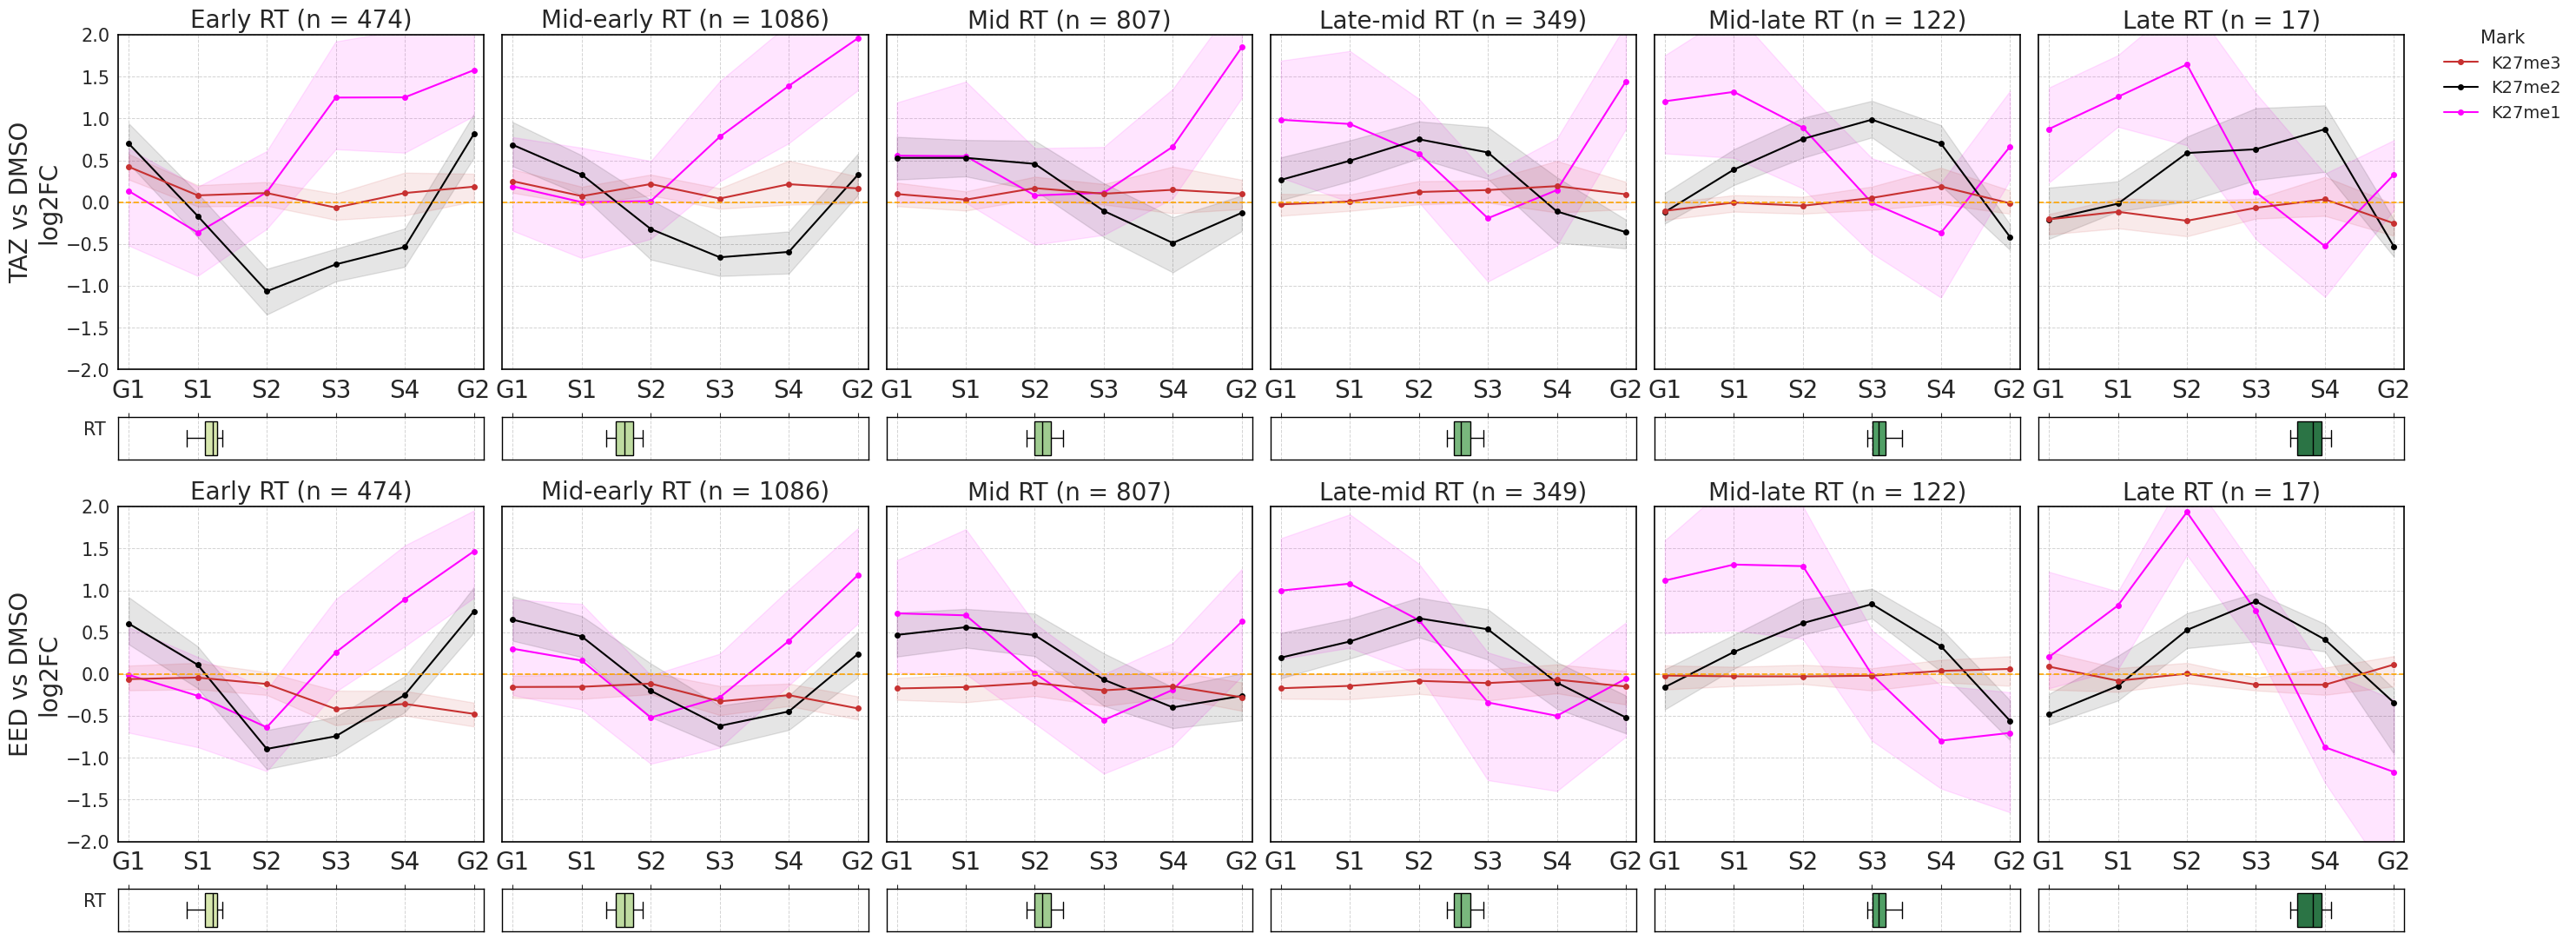

In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ------------------------------------------------------------
# Config
# ------------------------------------------------------------
marks = ['K27me3', 'K27me2', 'K27me1']
drugs = ['TAZ', 'EED']

stage_order = ['G1', 'S1', 'S2', 'S3', 'S4', 'G2']
stage_to_time = {'G1': 0.0, 'S1': 0.2, 'S2': 0.4, 'S3': 0.6, 'S4': 0.8, 'G2': 1.0}
xlow, xhi = -0.03, 1.03

color_palette = {
    'K27me3': '#C73131',
    'K27me2': '#000000',
    'K27ac':  '#22D0FB',
    'K27me1': '#FF00FF',
    'RNAPII': '#FFC60B'
}

# ------------------------------------------------------------
# Assume dfs are in this order:
# [K27me3, K27me2, K27me1, K27ac, RNAPII]
# ------------------------------------------------------------
full_mark_order = ['K27me3', 'K27me2', 'K27me1', 'K27ac', 'RNAPII']
mark_to_df = dict(zip(full_mark_order, dfs))
plot_dfs = [mark_to_df[m] for m in marks]

# ------------------------------------------------------------
# RT bins and labels
# ------------------------------------------------------------
rt_bins = np.linspace(
    np.quantile(rt_data["RT"].dropna(), 0.02),
    np.quantile(rt_data["RT"].dropna(), 0.98),
    num=7
)
rt_bins[0] = 0
rt_bins[-1] = 1

rt_labels = [
    "Early RT",
    "Mid-early RT",
    "Mid RT",
    "Late-mid RT",
    "Mid-late RT",
    "Late RT",
]

n_rows = len(drugs)
n_cols = len(rt_labels)

# ------------------------------------------------------------
# Helper
# ------------------------------------------------------------
def compute_long_log2fc(df, mark, drug, efs=0.01, shape_category="me3_domain"):
    df = df.copy()
    df.index = df.index.astype(str)

    df = df[
        ~df.index.str.startswith("TAF11L")
        & ~df.index.str.startswith("FAM90A")
        & ~df.index.str.startswith("USP17L")
    ].copy()

    if "RT" not in df.columns:
        raise ValueError(f"{mark} df is missing 'RT'")
    if "shape_category" not in df.columns:
        raise ValueError(f"{mark} df is missing 'shape_category'")

    df["RT_inv"] = 1.0 - df["RT"]
    df = df[df["shape_category"].eq(shape_category)].copy()

    df["rt_bin"] = pd.cut(
        df["RT_inv"],
        bins=rt_bins,
        labels=range(len(rt_labels)),
        include_lowest=True,
        right=True
    )

    df = df.dropna(subset=["rt_bin", "RT_inv"]).copy()
    df["rt_bin"] = df["rt_bin"].astype(int)

    long_list = []
    for stage in stage_order:
        col_drug = f"meanCPM_{stage}_{drug}"
        col_dmso = f"meanCPM_{stage}_DMSO"

        if col_drug not in df.columns or col_dmso not in df.columns:
            raise ValueError(f"{mark} df is missing {col_drug} or {col_dmso}")

        cpm_drug = df[col_drug].astype(float)
        cpm_dmso = df[col_dmso].astype(float)
        log2fc = np.log2((cpm_drug + efs) / (cpm_dmso + efs))

        tmp = pd.DataFrame({
            "gene": df.index.values,
            "stage": stage,
            "log2FC": log2fc.values,
            "rt_bin": df["rt_bin"].values,
            "RT_inv": df["RT_inv"].values,
            "mark": mark
        })

        tmp = tmp.replace([np.inf, -np.inf], np.nan).dropna(subset=["log2FC"])
        long_list.append(tmp)

    if not long_list:
        return pd.DataFrame(columns=["gene", "stage", "log2FC", "rt_bin", "RT_inv", "mark"])

    out = pd.concat(long_list, ignore_index=True)
    out["stage"] = pd.Categorical(out["stage"], categories=stage_order, ordered=True)
    return out

# ------------------------------------------------------------
# Figure layout: same logic as your working example
# ------------------------------------------------------------
fig = plt.figure(figsize=(28, 6 * n_rows))
gs = fig.add_gridspec(
    2 * n_rows, n_cols,
    height_ratios=[5.5, 0.7] * n_rows,
    hspace=0.25
)

last_ax = None

# ------------------------------------------------------------
# Build and plot row-by-row
# ------------------------------------------------------------
for row_idx, drug in enumerate(drugs):

    # combine all marks for this drug
    long_parts = []
    for mark, df in zip(marks, plot_dfs):
        x = compute_long_log2fc(df, mark, drug)
        if not x.empty:
            long_parts.append(x)

    if not long_parts:
        for col_idx in range(n_cols):
            ax = fig.add_subplot(gs[2 * row_idx, col_idx])
            ax.set_axis_off()
            ax2 = fig.add_subplot(gs[2 * row_idx + 1, col_idx])
            ax2.set_axis_off()
        continue

    all_long_df = pd.concat(long_parts, ignore_index=True)
    all_long_df["stage"] = pd.Categorical(
        all_long_df["stage"],
        categories=stage_order,
        ordered=True
    )

    # one unique RT value per gene for the boxplot row and counts
    rt_gene = (
        all_long_df[["gene", "rt_bin", "RT_inv"]]
        .drop_duplicates(subset=["gene"])
        .copy()
    )

    gene_counts = (
        rt_gene["rt_bin"]
        .value_counts(sort=False)
        .reindex(range(len(rt_labels)), fill_value=0)
        .astype(int)
    )

    # summary for line plots
    summary = (
        all_long_df
        .dropna(subset=["log2FC"])
        .groupby(["rt_bin", "mark", "stage"], observed=False)
        .agg(
            q25=("log2FC", lambda x: x.quantile(0.25)),
            median=("log2FC", "median"),
            q75=("log2FC", lambda x: x.quantile(0.75)),
        )
        .reset_index()
    )
    summary["stage"] = pd.Categorical(summary["stage"], categories=stage_order, ordered=True)

    # ------------------------------------------------------------
    # Plot line + RT box per column
    # ------------------------------------------------------------
    for col_idx, bin_id in enumerate(range(len(rt_labels))):
        ax = fig.add_subplot(gs[2 * row_idx, col_idx])
        last_ax = ax

        bin_data = summary[summary["rt_bin"] == bin_id]

        for mark, mark_data in bin_data.groupby("mark", sort=False):
            mark_data = mark_data.sort_values("stage")
            x_vals = mark_data["stage"].map(stage_to_time).astype(float).values

            ax.plot(
                x_vals,
                mark_data["median"].values,
                label=mark,
                color=color_palette.get(mark, "gray"),
                marker="o",
                markersize=4,
                linewidth=1.5
            )
            ax.fill_between(
                x_vals,
                mark_data["q25"].values,
                mark_data["q75"].values,
                color=color_palette.get(mark, "gray"),
                alpha=0.10
            )

        ax.set_xlim(xlow, xhi)
        ax.set_ylim(-2, 2)
        ax.set_xticks(list(stage_to_time.values()))
        ax.set_xticklabels(stage_order, rotation=0, ha="center", fontsize=20)
        ax.set_title(f"{rt_labels[bin_id]} (n = {int(gene_counts.loc[bin_id])})", fontsize=20)
        ax.grid(axis="both", color="lightgray", linestyle="--", linewidth=0.7)
        ax.axhline(0, color="orange", linestyle="--", linewidth=1.2)

        if col_idx == 0:
            ax.set_ylabel(f"{drug} vs DMSO\nlog2FC", fontsize=20)
        else:
            ax.set_yticklabels([])

        for spine in ax.spines.values():
            spine.set_edgecolor("black")
            spine.set_linewidth(1.2)

        # --- RT boxplot directly below this row, same logic as working example ---
        ax2 = fig.add_subplot(gs[2 * row_idx + 1, col_idx])
        subset = rt_gene.loc[rt_gene["rt_bin"] == bin_id, "RT_inv"].dropna()

        if subset.empty:
            ax2.set_axis_off()
            continue

        median_rt = float(subset.median())
        norm = mcolors.Normalize(vmin=0, vmax=1)
        cmap = plt.get_cmap("YlGn")
        box_color = cmap(norm(median_rt))

        sns.boxplot(
            x=subset.values,
            ax=ax2,
            color=box_color,
            fliersize=0,
            linewidth=1,
            linecolor="black",
            orient="h"
        )

        ax2.set_xlim(xlow, xhi)
        ax2.grid(axis="x", linestyle="--", color="lightgray", linewidth=0.7)
        ax2.set_xticks(list(stage_to_time.values()))
        ax2.set_xticklabels("")   # same as working example
        ax2.set_yticks([])

        ax2.xaxis.tick_top()
        ax2.tick_params(labelbottom=False, labeltop=False)

        if col_idx == 0:
            ax2.set_ylabel("RT", rotation=0, labelpad=20)
        else:
            ax2.set_ylabel("")

        for spine in ax2.spines.values():
            spine.set_edgecolor("black")
            spine.set_linewidth(1)

# ------------------------------------------------------------
# Shared legend
# ------------------------------------------------------------
if last_ax is not None:
    handles, labels = last_ax.get_legend_handles_labels()
    ordered_labels = [m for m in marks if m in color_palette]
    pairs = [(h, l) for h, l in zip(handles, labels) if l in ordered_labels]

    # deduplicate
    seen = set()
    pairs = [(h, l) for h, l in pairs if not (l in seen or seen.add(l))]

    if pairs:
        pairs.sort(key=lambda x: ordered_labels.index(x[1]))
        hs, ls = zip(*pairs)
        fig.legend(
            hs, ls,
            title="Mark",
            bbox_to_anchor=(0.98, 0.95),
            loc="upper left",
            frameon=False,
            fontsize=14
        )

fig.subplots_adjust(
    left=0.03, right=0.97,
    top=0.93, bottom=0.07,
    wspace=0.05,
    hspace=0.1
)
fig.savefig(os.path.join(fig_dir, f"20260309_Drug_dynamics_lineplot.pdf"),
            bbox_inches="tight")
plt.show()

# Heatmaps

/loc/scratch/64485112/ipykernel_24432/4110719154.py:223: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap(rt_cmap, len(rt_labels)),
/loc/scratch/64485112/ipykernel_24432/4110719154.py:223: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap(rt_cmap, len(rt_labels)),
/loc/scratch/64485112/ipykernel_24432/4110719154.py:223: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap(rt_cmap, len(rt_labels)),
/loc/scratch/644

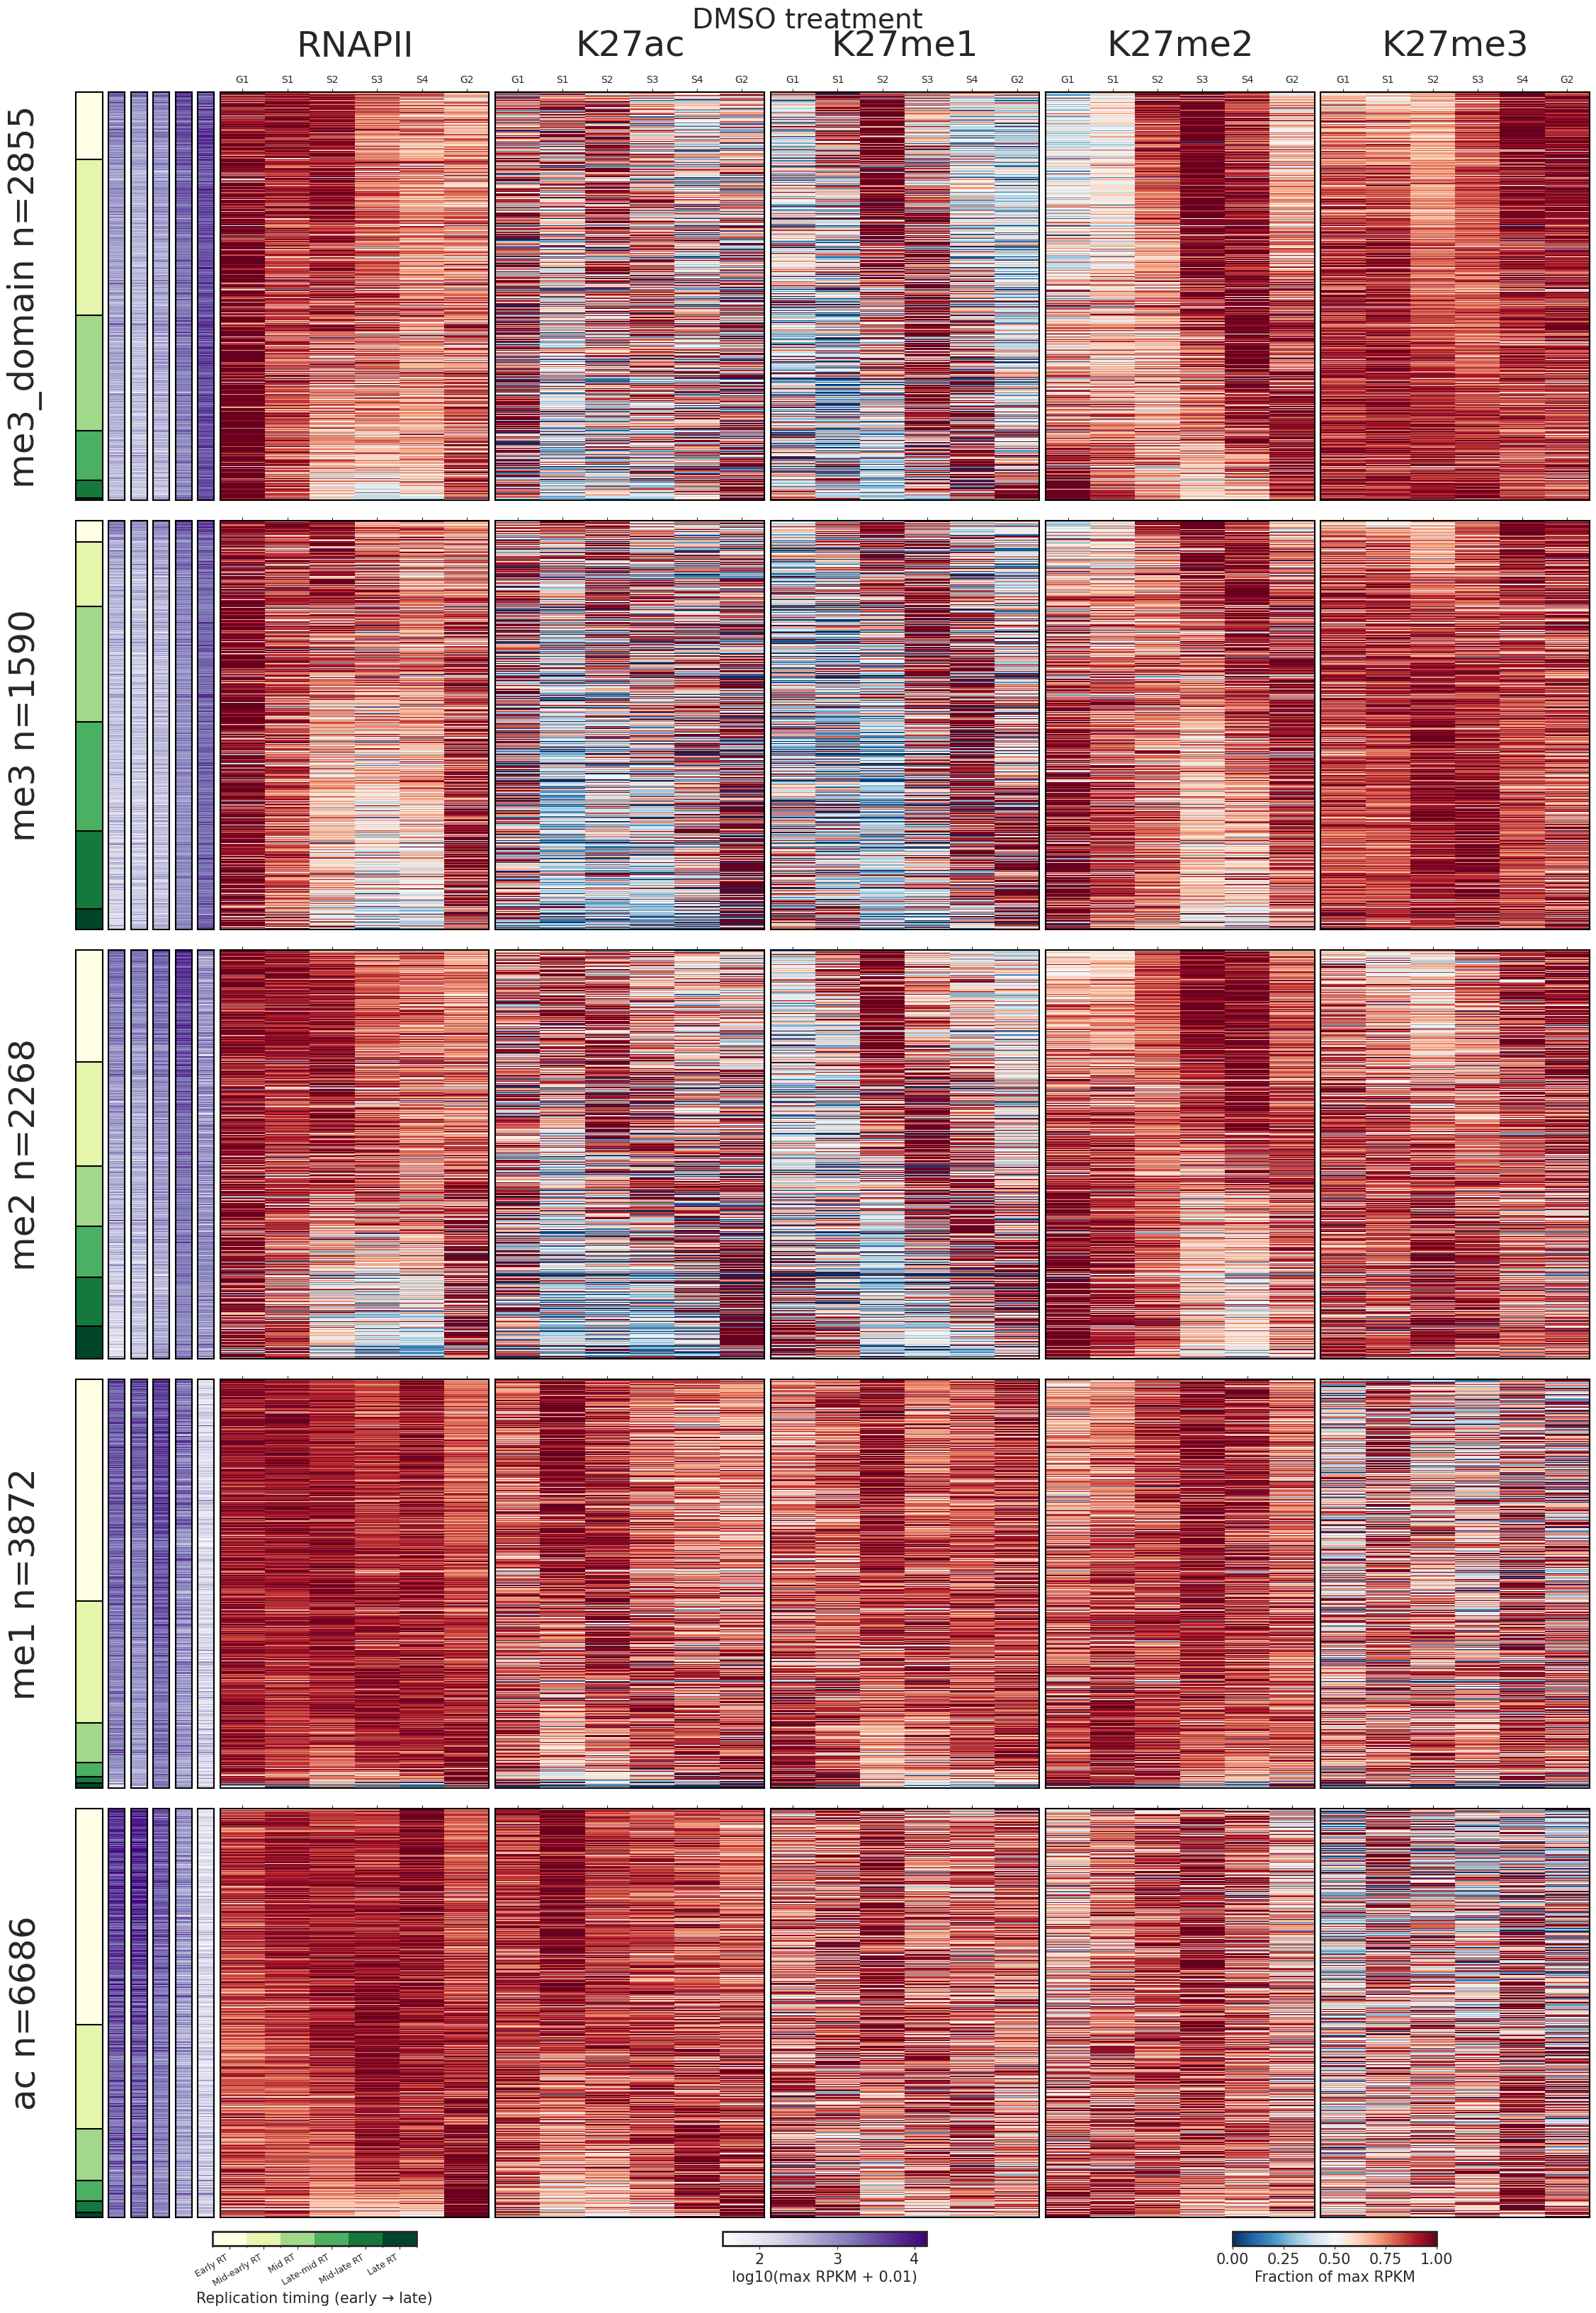

/loc/scratch/64485112/ipykernel_24432/4110719154.py:223: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap(rt_cmap, len(rt_labels)),
/loc/scratch/64485112/ipykernel_24432/4110719154.py:223: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap(rt_cmap, len(rt_labels)),
/loc/scratch/64485112/ipykernel_24432/4110719154.py:223: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap(rt_cmap, len(rt_labels)),
/loc/scratch/644

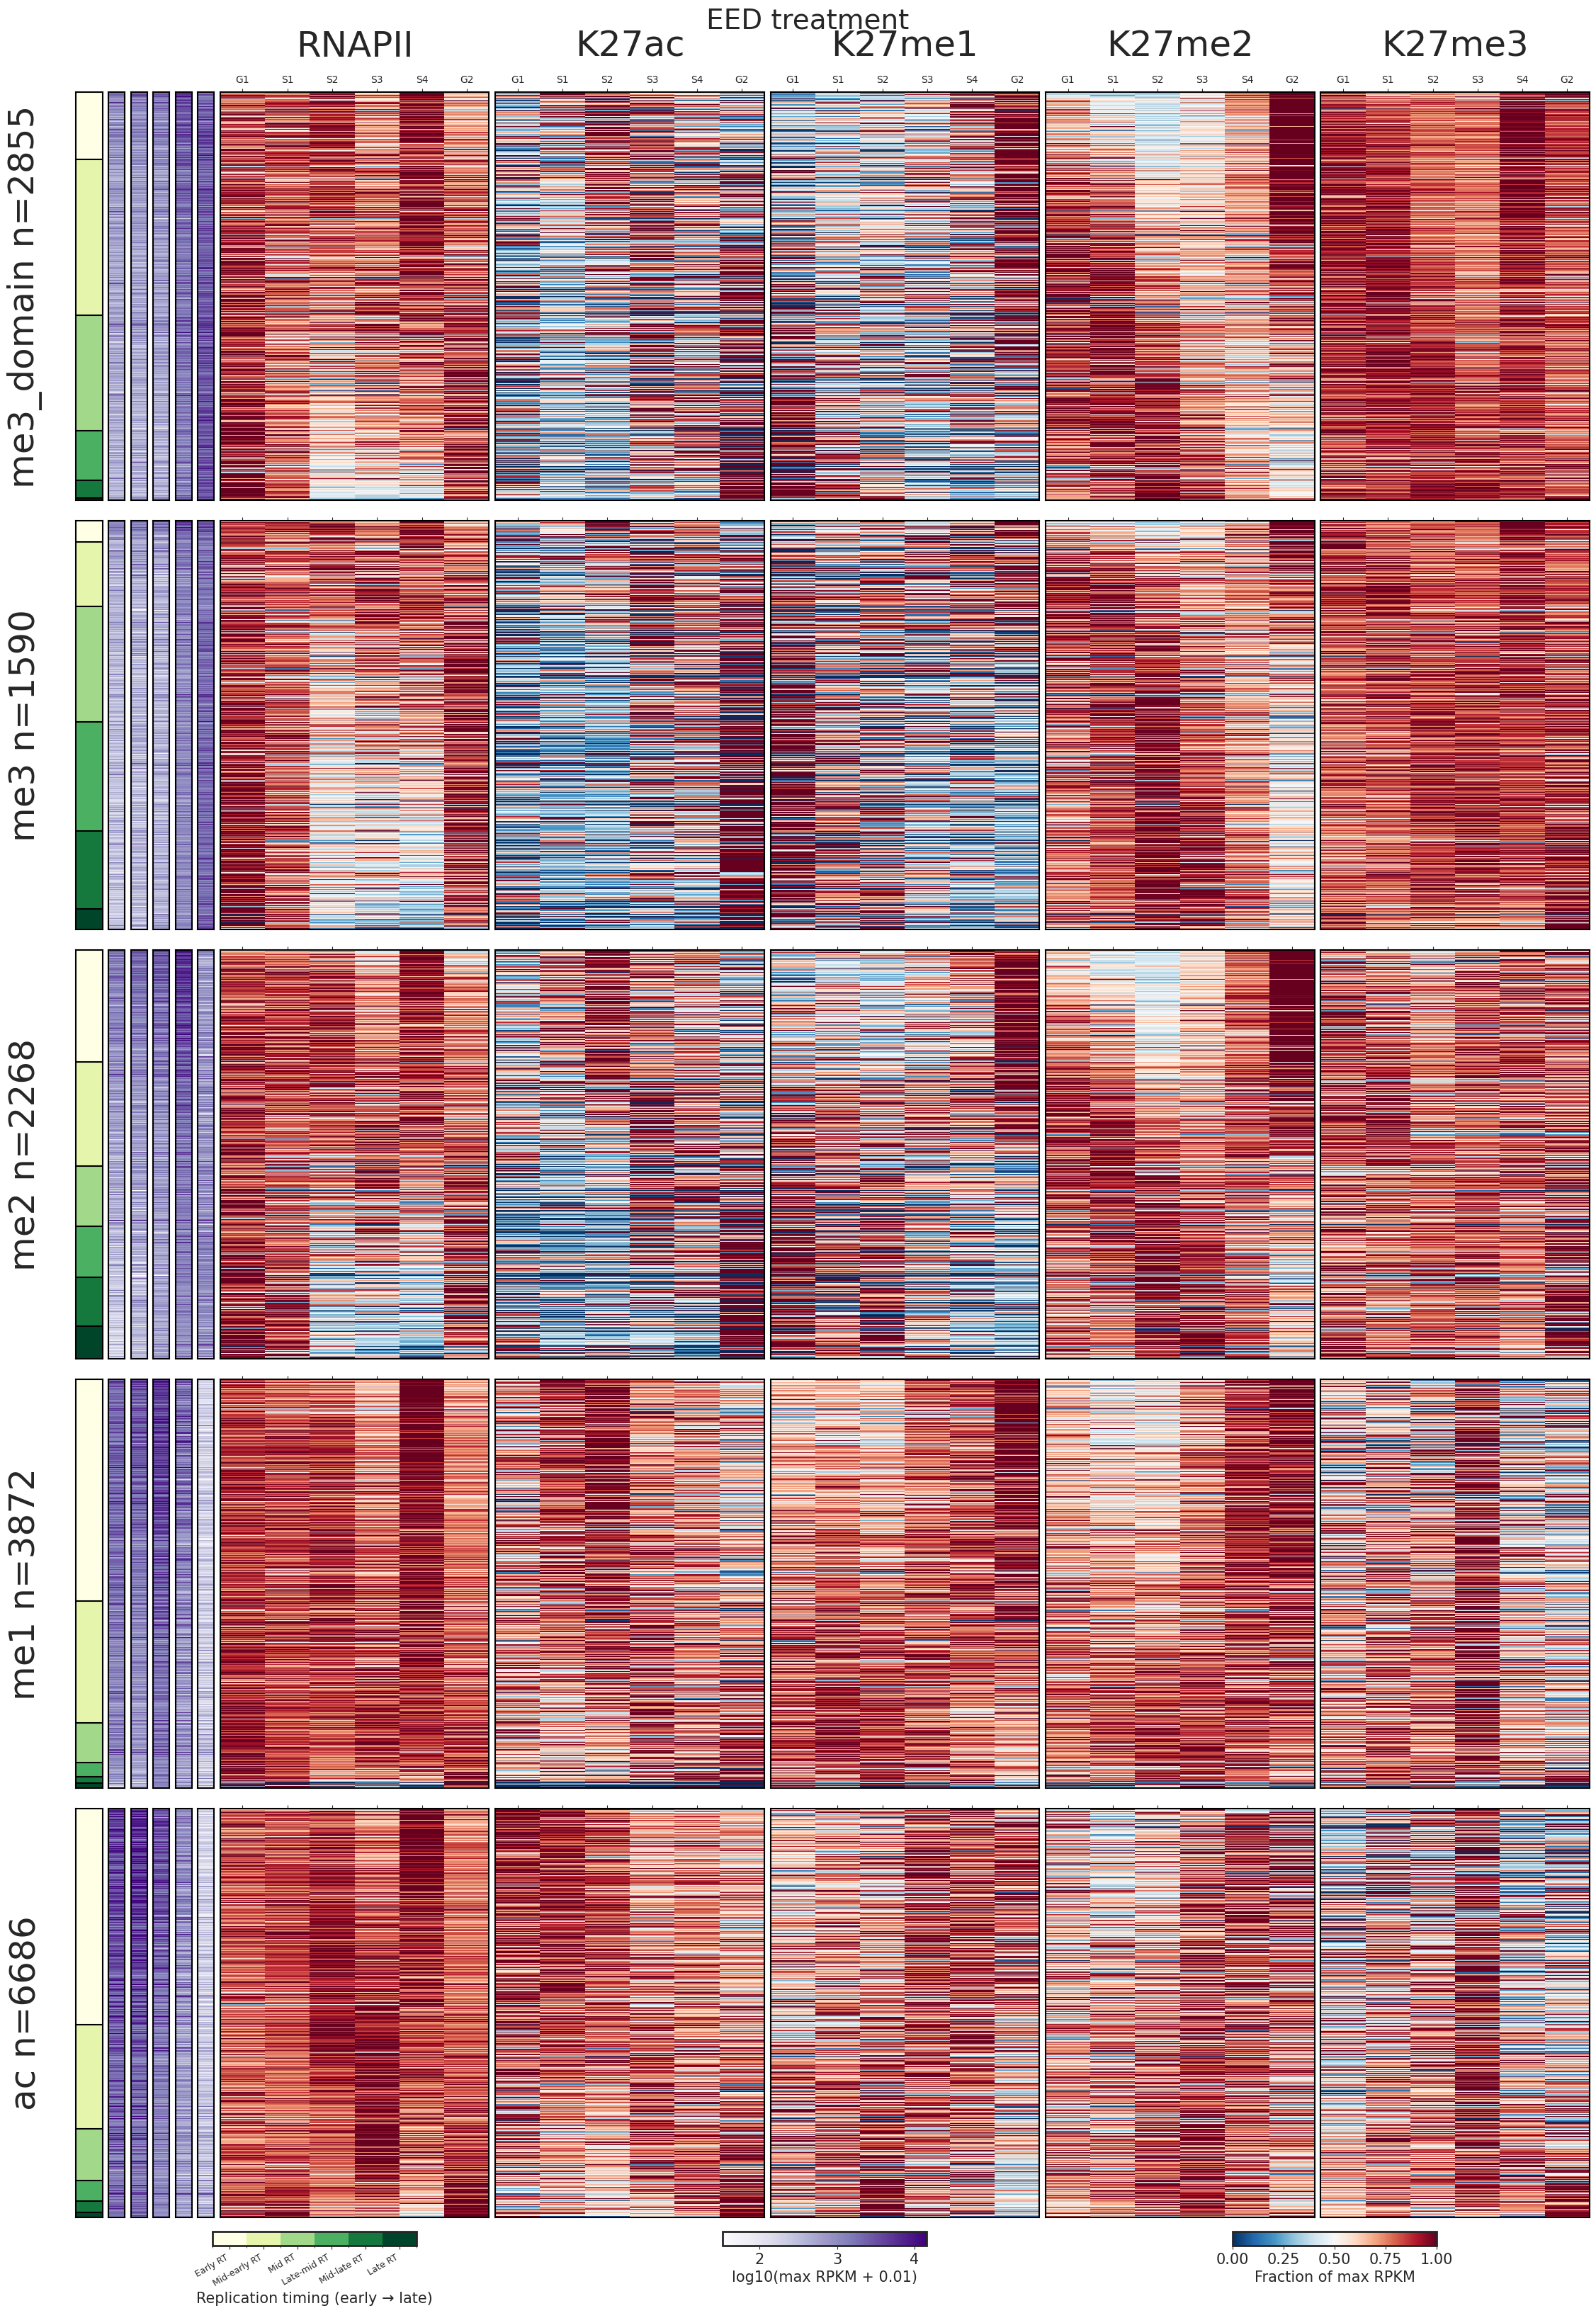

/loc/scratch/64485112/ipykernel_24432/4110719154.py:223: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap(rt_cmap, len(rt_labels)),
/loc/scratch/64485112/ipykernel_24432/4110719154.py:223: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap(rt_cmap, len(rt_labels)),
/loc/scratch/64485112/ipykernel_24432/4110719154.py:223: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap(rt_cmap, len(rt_labels)),
/loc/scratch/644

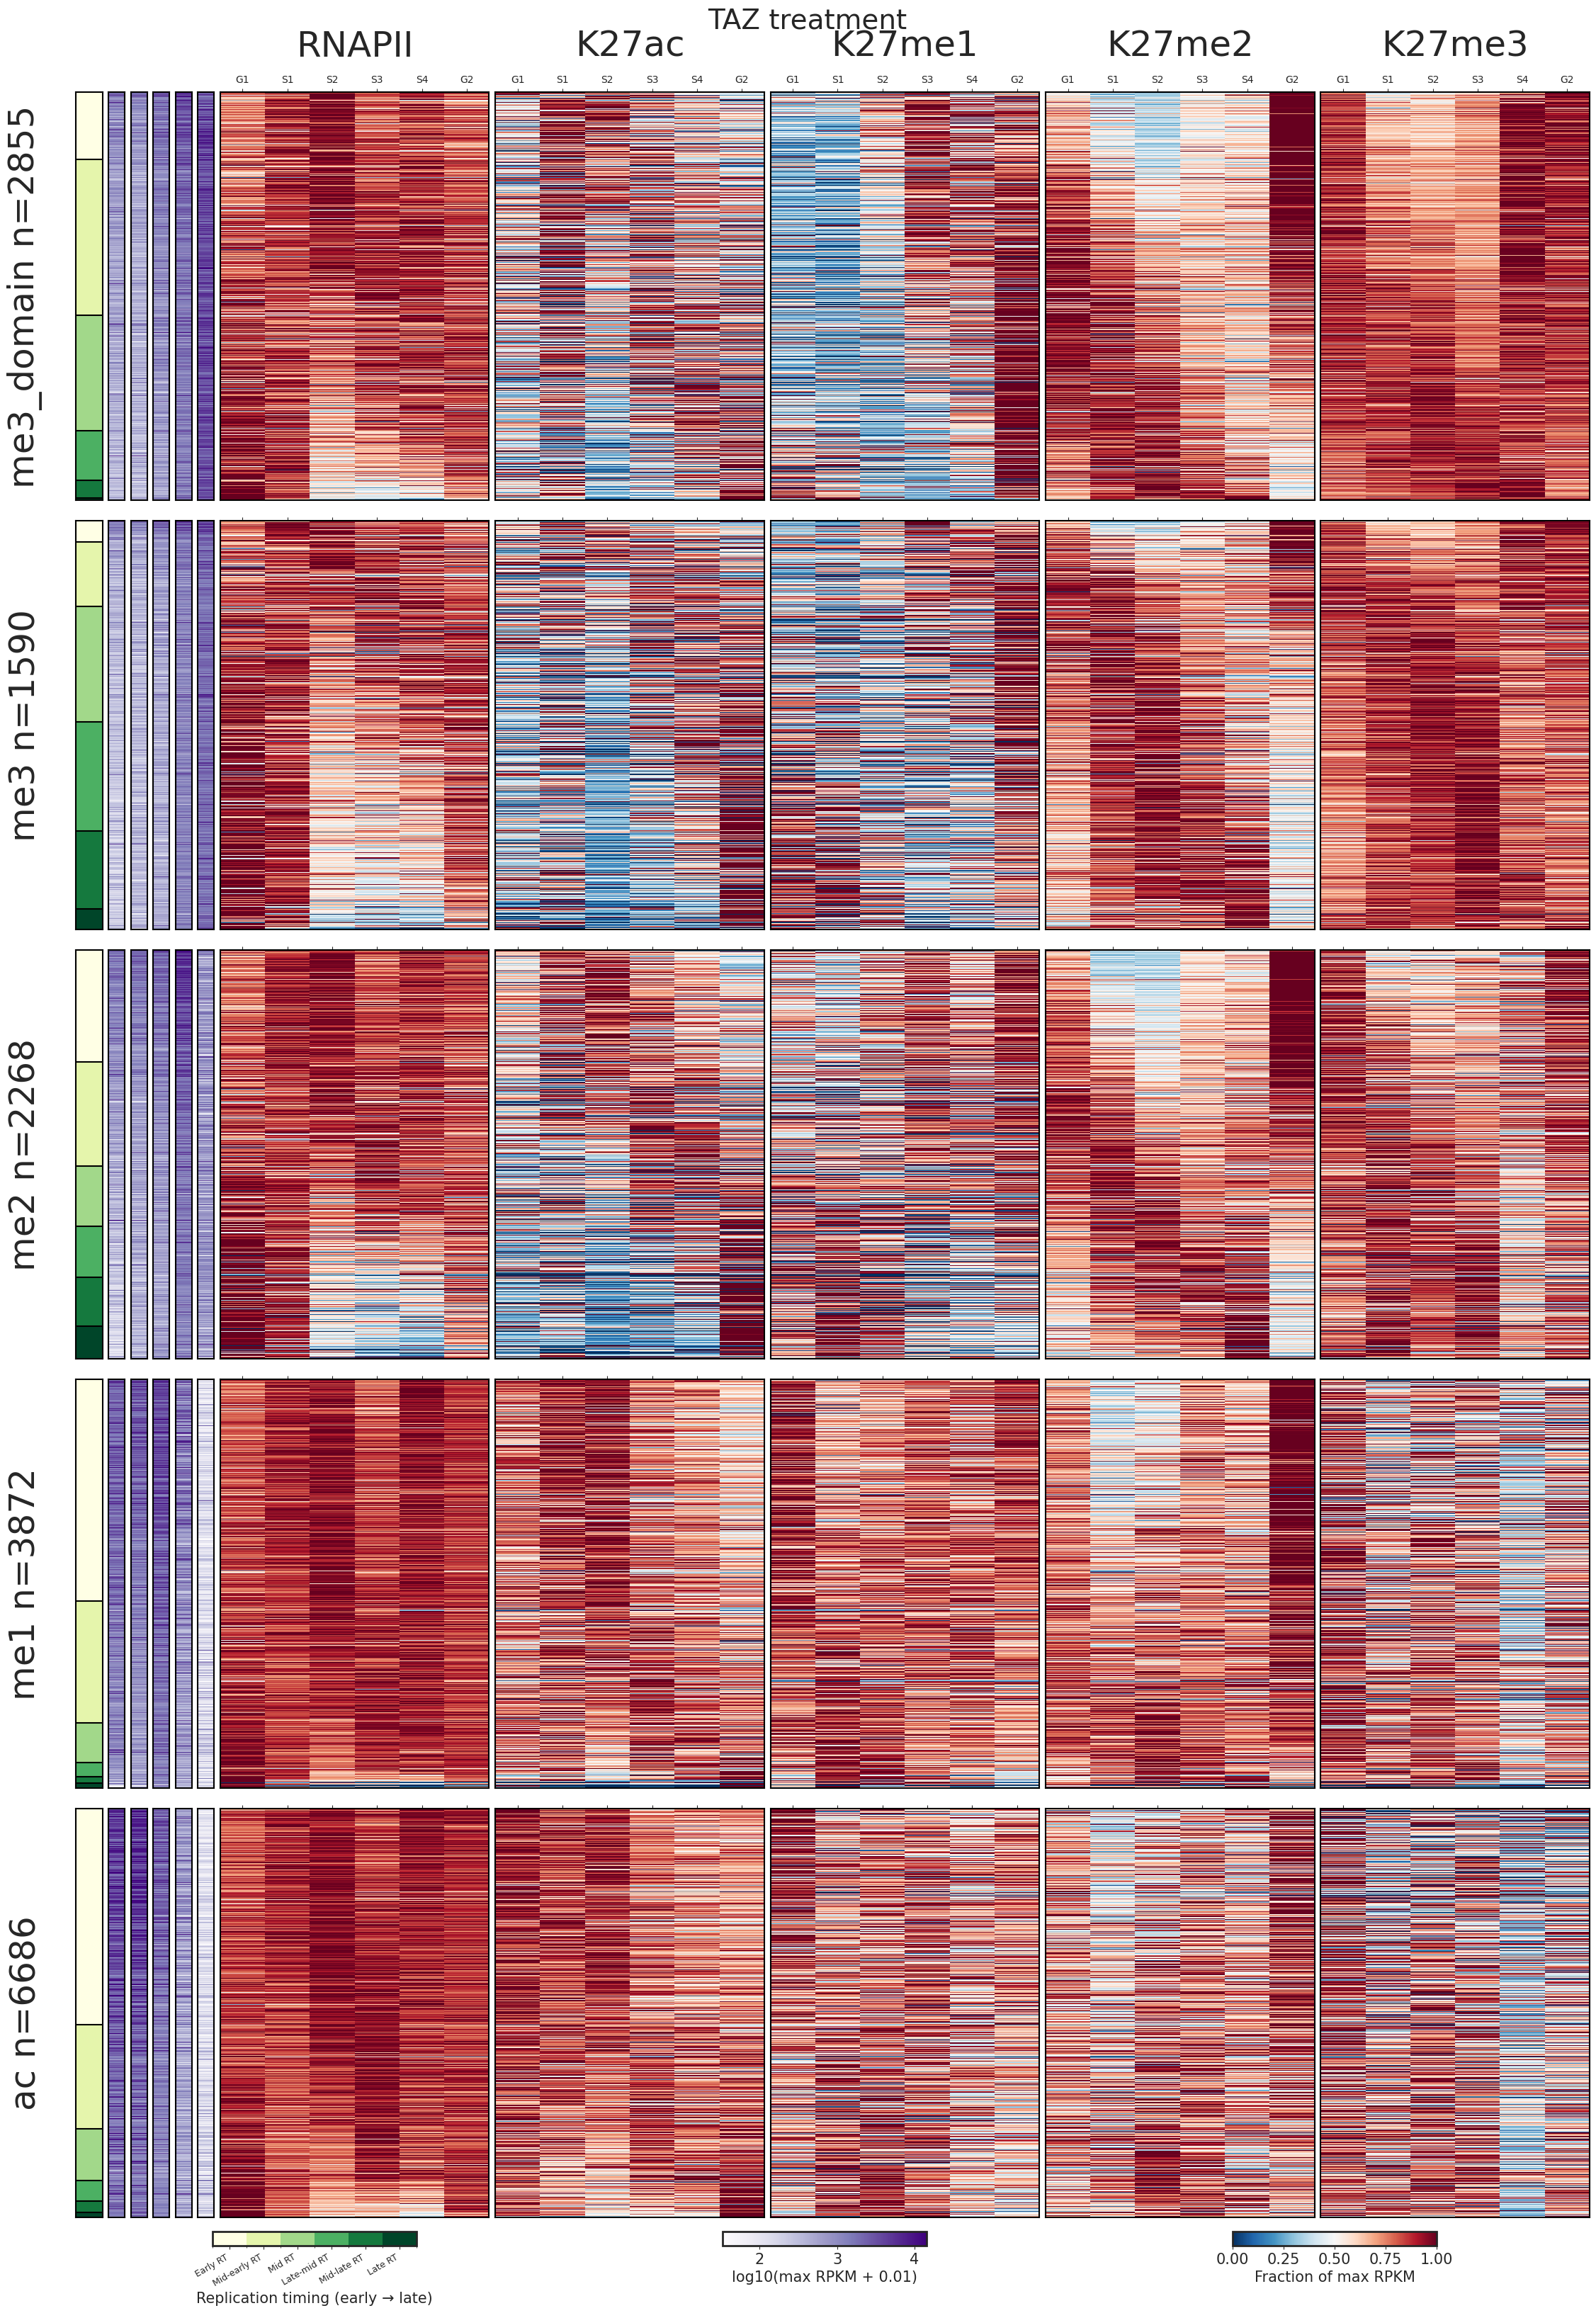

In [17]:
import os
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# ————————————————————————————————————————————
# Helper
def add_frame(ax, lw=1.5):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(lw)

# ————————————————————————————————————————————
# Configuration
categories = ["me3_domain", "me3", "me2", "me1", "ac"]
marks = ["K27me3", "K27me2", "K27me1", "K27ac", "RNAPII"]
histone_marks = ["K27me3", "K27me2", "K27me1", "K27ac"]
drugs = ["DMSO", "EED", "TAZ"]

# plotting order for grouped bars and grouped heatmaps
plot_marks = ["RNAPII", "K27ac", "K27me1", "K27me2", "K27me3"]

rt_cmap = "YlGn"
hm_cmap = "RdBu_r"
rpkm_cmap = "Purples"
xlabels = ["G1", "S1", "S2", "S3", "S4", "G2"]

stages = ["G1", "S1", "S2", "S3", "S4", "G2"]
CPM_PREFIX = "meanCPM"

# replication timing bins
rt_bins = np.linspace(
    np.quantile(rt_data["RT"].dropna(), 0.02),
    np.quantile(rt_data["RT"].dropna(), 0.98),
    num=7
)
rt_bins[0] = 0
rt_bins[6] = 1
cutoffs = rt_bins
rt_labels = [
    "Early RT",
    "Mid-early RT",
    "Mid RT",
    "Late-mid RT",
    "Mid-late RT",
    "Late RT",
]

# ————————————————————————————————————————————
# Heatmap normalization mode
GLOBAL_SCALE = False
THRESH_EXPR = 0

# ————————————————————————————————————————————
# 1) Compute RPKM matrices from CPM + length
rpkm_by_drug = {drug: {} for drug in drugs}

for mark, df_mark in zip(marks, dfs):
    if not {"start", "end"}.issubset(df_mark.columns):
        raise ValueError(f"df for mark {mark} must contain 'start' and 'end' columns")

    length_bp = df_mark["end"] - df_mark["start"]
    length_kb = length_bp / 1000.0
    length_kb_safe = length_kb.replace(0, np.nan)

    for drug in drugs:
        cpm_cols = [
            f"{CPM_PREFIX}_{s}_{drug}"
            for s in stages
            if f"{CPM_PREFIX}_{s}_{drug}" in df_mark.columns
        ]
        if not cpm_cols:
            continue

        cpm_mat = df_mark[cpm_cols].copy()
        rpkm_mat = cpm_mat.mul(1e3).div(length_kb_safe, axis=0).fillna(0)

        rpkm_mat.columns = [c.split("_")[1] for c in cpm_cols]
        rpkm_mat = rpkm_mat[[s for s in stages if s in rpkm_mat.columns]]

        rpkm_by_drug[drug][mark] = rpkm_mat

# ————————————————————————————————————————————
# 2) Global max per gene × mark across all drugs × stages
global_max_per_mark = {}
per_drug_max_per_mark = {drug: {} for drug in drugs}

for mark in marks:
    mats_for_global = []

    for drug in drugs:
        mat = rpkm_by_drug[drug].get(mark)
        if mat is None:
            continue

        per_drug_max_per_mark[drug][mark] = mat.max(axis=1)
        mats_for_global.append(mat)

    if not mats_for_global:
        raise ValueError(f"No RPKM matrices found for mark {mark} across drugs")

    all_mat = pd.concat(mats_for_global, axis=1)
    gmax = all_mat.max(axis=1)

    if THRESH_EXPR > 0:
        keep = gmax >= THRESH_EXPR
        gmax = gmax[keep]
        for drug in drugs:
            if mark in rpkm_by_drug[drug]:
                rpkm_by_drug[drug][mark] = rpkm_by_drug[drug][mark].loc[gmax.index]
            if mark in per_drug_max_per_mark[drug]:
                per_drug_max_per_mark[drug][mark] = per_drug_max_per_mark[drug][mark].loc[gmax.index]

    global_max_per_mark[mark] = gmax

# ————————————————————————————————————————————
# 3) Bar values and shared bar color scale
bar_vals_by_drug = {drug: {} for drug in drugs}
all_bar_logs = []

for drug in drugs:
    for mark in marks:
        s = per_drug_max_per_mark[drug].get(mark)
        if s is None:
            continue
        log_s = np.log10(s + 0.01)
        bar_vals_by_drug[drug][mark] = log_s

        if mark in histone_marks:
            all_bar_logs.append(log_s.values)

if all_bar_logs:
    bar_all_vals = np.concatenate(all_bar_logs)
    bar_r_max = np.nanquantile(bar_all_vals, 0.99)
    bar_r_min = np.nanquantile(bar_all_vals, 0.01)
else:
    bar_r_max = 0.0
    bar_r_min = -2.0

# ————————————————————————————————————————————
# 4) Build normalized heatmaps per drug
norm_by_drug = {drug: {} for drug in drugs}

for mark in marks:
    gmax = global_max_per_mark[mark]

    for drug in drugs:
        mat = rpkm_by_drug[drug].get(mark, None)
        if mat is None:
            continue

        if GLOBAL_SCALE:
            denom = gmax
        else:
            denom = per_drug_max_per_mark[drug][mark]

        denom_safe = denom.replace(0, np.nan)
        norm_mat = mat.div(denom_safe, axis=0).fillna(0)

        norm_by_drug[drug][mark] = norm_mat

# ————————————————————————————————————————————
# 5) Make one figure per drug
for drug in drugs:
    hm_dict = norm_by_drug[drug]
    bar_dict = bar_vals_by_drug[drug]

    n_rows = len(categories)
    fig = plt.figure(figsize=(24, 8 * n_rows))
    grid = fig.add_gridspec(
        n_rows, 12,
        left=0.05, right=0.96, top=0.93, bottom=0.18,
        hspace=0.05, wspace=0.05,
        width_ratios=[
            0.10,  # label
            0.10,  # RT
            0.06, 0.06, 0.06, 0.06, 0.06,  # grouped purple strips
            1, 1, 1, 1, 1                  # grouped heatmaps
        ]
    )

    fig.suptitle(f"{drug} treatment", fontsize=28, y=0.96)

    for row_idx, cat_name in enumerate(categories):
        common = set().union(*[hm.index for hm in hm_dict.values()])
        common = common.intersection(rt_data.loc[rt_data["shape_category"] == cat_name].index)

        rt = bins_idx.loc[list(common), "RT"].dropna()
        rt = 1 - rt
        rt = rt.sort_values()
        genes = rt.index

        hm_data = {m: hm_dict[m].reindex(genes) for m in plot_marks}
        bar_data = {
            m: (bar_dict[m].reindex(genes) if m in bar_dict else None)
            for m in plot_marks
        }

        axes = [fig.add_subplot(grid[row_idx, i]) for i in range(12)]
        (
            ax_label, ax_rt,
            ax_r_rnapII, ax_r_ac, ax_r_me1, ax_r_me2, ax_r_me3,
            ax_hm_rnapII, ax_hm_ac, ax_hm_me1, ax_hm_me2, ax_hm_me3
        ) = axes

        # category label
        ax_label.axis("off")
        ax_label.text(
            0, 0.5, f"{cat_name} n={len(genes)}",
            fontsize=36, va="center", ha="right", rotation=90,
            transform=ax_label.transAxes
        )

        # RT stripe
        rt_binned = pd.cut(rt, bins=rt_bins, labels=False, include_lowest=True).astype(float)

        sns.heatmap(
            rt_binned.values[:, None],
            ax=ax_rt,
            cmap=plt.cm.get_cmap(rt_cmap, len(rt_labels)),
            vmin=0, vmax=len(rt_labels) - 1,
            cbar=False, xticklabels=False, yticklabels=False
        )

        bin_edges = [np.searchsorted(rt_binned.values, i) for i in range(1, len(rt_labels))]
        for edge in bin_edges:
            ax_rt.hlines(edge, *ax_rt.get_xlim(), colors="black", linewidth=1.5)
        add_frame(ax_rt)

        # grouped purple strips
        rpkm_axes = {
            "RNAPII": ax_r_rnapII,
            "K27ac": ax_r_ac,
            "K27me1": ax_r_me1,
            "K27me2": ax_r_me2,
            "K27me3": ax_r_me3,
        }

        for mark, ax in rpkm_axes.items():
            s = bar_data[mark]
            if s is not None:
                sns.heatmap(
                    s.to_frame(),
                    ax=ax,
                    cmap=rpkm_cmap,
                    vmin=bar_r_min, vmax=bar_r_max,
                    cbar=False,
                    xticklabels=False, yticklabels=False,
                    mask=s.isna().to_frame()
                )
                add_frame(ax)
                ax.set_ylabel("")
            else:
                ax.axis("off")

        # grouped fraction heatmaps
        hm_axes = {
            "RNAPII": ax_hm_rnapII,
            "K27ac": ax_hm_ac,
            "K27me1": ax_hm_me1,
            "K27me2": ax_hm_me2,
            "K27me3": ax_hm_me3,
        }

        for mark, ax in hm_axes.items():
            mat = hm_data[mark]
            sns.heatmap(
                mat,
                ax=ax,
                cmap=hm_cmap,
                vmin=0, vmax=1,
                cbar=False,
                xticklabels=True, yticklabels=False,
                mask=mat.isna()
            )
            ax.set_xticklabels(xlabels, ha="center", rotation=0, fontsize=10)
            ax.xaxis.tick_top()
            add_frame(ax)
            ax.set_ylabel("")

        if row_idx == 0:
            ax_hm_rnapII.text(0.5, 1.07, "RNAPII", fontsize=36,
                              ha="center", va="bottom", transform=ax_hm_rnapII.transAxes)
            ax_hm_ac.text(0.5, 1.07, "K27ac", fontsize=36,
                          ha="center", va="bottom", transform=ax_hm_ac.transAxes)
            ax_hm_me1.text(0.5, 1.07, "K27me1", fontsize=36,
                           ha="center", va="bottom", transform=ax_hm_me1.transAxes)
            ax_hm_me2.text(0.5, 1.07, "K27me2", fontsize=36,
                           ha="center", va="bottom", transform=ax_hm_me2.transAxes)
            ax_hm_me3.text(0.5, 1.07, "K27me3", fontsize=36,
                           ha="center", va="bottom", transform=ax_hm_me3.transAxes)

        if row_idx != 0:
            for ax in hm_axes.values():
                ax.set_xticklabels([])
            for ax in rpkm_axes.values():
                ax.set_xticklabels([])

    # ————————————————————————————————————————————
    # Shared colorbars
    cbar_y = 0.17
    cbar_h = 0.005
    cbar_w = 0.12

    # RT
    cax_rt = fig.add_axes([0.15, cbar_y, cbar_w, cbar_h])
    cmap_rt = plt.cm.get_cmap(rt_cmap, len(rt_labels))
    bounds = np.arange(len(rt_labels) + 1) - 0.5
    norm = mpl.colors.BoundaryNorm(bounds, cmap_rt.N)
    cb = mpl.colorbar.ColorbarBase(
        cax_rt, cmap=cmap_rt, norm=norm,
        boundaries=bounds, ticks=np.arange(len(rt_labels)),
        orientation="horizontal"
    )
    cb.ax.set_xticklabels(rt_labels, rotation=30, ha="right", fontsize=9)
    cb.set_label("Replication timing (early → late)")

    # RPKM strips
    cax_rpkm = fig.add_axes([0.45, cbar_y, cbar_w, cbar_h])
    sm_rpkm = plt.cm.ScalarMappable(
        cmap=rpkm_cmap,
        norm=plt.Normalize(bar_r_min, bar_r_max)
    )
    plt.colorbar(
        sm_rpkm, cax=cax_rpkm, orientation="horizontal",
        label="log10(max RPKM + 0.01)"
    )

    # fraction heatmaps
    cax_main = fig.add_axes([0.75, cbar_y, cbar_w, cbar_h])
    sm_main = plt.cm.ScalarMappable(
        cmap=hm_cmap,
        norm=plt.Normalize(0, 1)
    )
    plt.colorbar(
        sm_main, cax=cax_main, orientation="horizontal",
        label="Fraction of max RPKM"
    )

    plt.tight_layout()
    fig.savefig(
        os.path.join(fig_dir, f"20260217_Sup4b_{drug}_heatmaps_scaledPerDrug.pdf"),
        bbox_inches="tight"
    )

    plt.show()